<a href="https://colab.research.google.com/github/miquelaingalls/Tonian-Phosphate/blob/main/Urist_et_al_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

# Replace 'path/to/your/excel_file.xlsx' with the actual path to your Excel file in Google Drive
excel_file_path = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Data_All_S1.xlsx"

# Get all sheet names from the Excel file
xcl = pd.ExcelFile(excel_file_path)
sheet_names = xcl.sheet_names

# Print the detected sheet names
print("Detected Sheet Names:", sheet_names)

# Initialize an empty list to store dataframes from each sheet
all_sheets_data = []

# Loop through each sheet, read its data, add 'Period' column, and append to the list
for sheet_name in sheet_names:
    df = pd.read_excel(excel_file_path, sheet_name=sheet_name)
    df['Period'] = sheet_name
    all_sheets_data.append(df)

# Concatenate all dataframes into a single dataframe, aligning columns with the same names
# and preserving all other columns. 'concat' handles this automatically with default settings.
combined_df = pd.concat(all_sheets_data, ignore_index=True)

Detected Sheet Names: ['Neoarchean', 'Paleoproterozoic', 'Mid-Proterozoic', 'Tonian', 'Ediacaran', 'Paleozoic', 'Cenozoic']


In [ ]:
import numpy as np
import pandas as pd # Import pandas here

# Ensure 'Percent Digested (%)' is numeric and handle potential errors
combined_df['Percent Digested (%)'] = pd.to_numeric(combined_df['Percent Digested (%)'], errors='coerce')

# Ensure 'Total CAP (mmol/mol)' is numeric and handle potential errors
combined_df['Total CAP (mmol/mol)'] = pd.to_numeric(combined_df['Total CAP (mmol/mol)'], errors='coerce')

# Print shape of combined_df before any filtering
print(f"Initial combined_df shape: {combined_df.shape}")

# Filter the data to include only rows where 'Percent Digested (%)' is > 60 and < 95
filtered_df_step1 = combined_df[
    (combined_df['Percent Digested (%)'] > 60) &
    (combined_df['Percent Digested (%)'] < 95)
].copy()

# Print shape after first filter
print(f"Shape after 'Percent Digested' filter (>60 and <95): {filtered_df_step1.shape}")

# Filter out 'Pethei' locations from the new 'mid-Proterozoic' period
filtered_df_step2 = filtered_df_step1[filtered_df_step1['Location'] != 'Pethei'].copy()

# Print shape after second filter
print(f"Shape after excluding 'Pethei': {filtered_df_step2.shape}")

# Filter out rows where 'Total CAP (mmol/mol)' is NaN
filtered_df = filtered_df_step2.dropna(subset=['Total CAP (mmol/mol)']).copy()

# Print shape after final filter
print(f"Final filtered_df shape (excluding 'Pethei' and NaN 'Total CAP'): {filtered_df.shape}")

output_excel_path_filtered_df = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/filtered_dataframe.xlsx"
if 'filtered_df' in locals() and not filtered_df.empty:
  filtered_df.to_excel(output_excel_path_filtered_df, index=False)
  print(f"'filtered_df' successfully saved to {output_excel_path_filtered_df}")
else:
  print("Error: 'filtered_df' DataFrame not found or is empty.")

Initial combined_df shape: (2993, 49)
Shape after 'Percent Digested' filter (>60 and <95): (2411, 49)
Shape after excluding 'Pethei': (2361, 49)
Final filtered_df shape (excluding 'Pethei' and NaN 'Total CAP'): (1898, 49)
'filtered_df' successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/filtered_dataframe.xlsx


In [ ]:
import seaborn as sns

# Define the full list of periods including the grouped Neoproterozoic
# Ensure all individual periods that form Neoproterozoic are also listed if they are to be plotted individually elsewhere
universal_period_order = [
    'Neoarchean', 'Paleoproterozoic', 'Mid-Proterozoic', 'Neoproterozoic',
    'Tonian', 'Ediacaran', 'Paleozoic','Cenozoic'
]

# Generate a color palette for all unique period names in universal_period_order
# This ensures a distinct color is initially generated for each period
base_palette_colors = sns.color_palette("viridis", n_colors=len(universal_period_order))
universal_color_map = {period: color for period, color in zip(universal_period_order, base_palette_colors)}

# Get the color assigned to Tonian
tonian_color = universal_color_map['Tonian']

# Assign the Tonian color to Neoproterozoic
universal_color_map['Neoproterozoic'] = tonian_color

# Print the defined universal_period_order and the generated universal_color_map
print("Universal Period Order:", universal_period_order)
print("Universal Color Map (with Neoproterozoic sharing Tonian's color):")
for period, color in universal_color_map.items():
    print(f"  {period}: {color}")

Universal Period Order: ['Neoarchean', 'Paleoproterozoic', 'Mid-Proterozoic', 'Neoproterozoic', 'Tonian', 'Ediacaran', 'Paleozoic', 'Cenozoic']
Universal Color Map (with Neoproterozoic sharing Tonian's color):
  Neoarchean: (0.281412, 0.155834, 0.469201)
  Paleoproterozoic: (0.244972, 0.287675, 0.53726)
  Mid-Proterozoic: (0.190631, 0.407061, 0.556089)
  Neoproterozoic: (0.119699, 0.61849, 0.536347)
  Tonian: (0.119699, 0.61849, 0.536347)
  Ediacaran: (0.20803, 0.718701, 0.472873)
  Paleozoic: (0.430983, 0.808473, 0.346476)
  Cenozoic: (0.709898, 0.868751, 0.169257)


# Statistical comparison of CAP syn- and pre-/post-BSA

This section calculates the mean and quartiles of CAP values in time bins, with the Tonian being considered with and without the syn-BSA values in all basins.

In [ ]:
print("Summary Statistics for 'Total CAP (mmol/mol)' by all Geological Periods: BSA filtering")
if 'filtered_df' in locals() and not filtered_df.empty:
    summary_stats_filtered_periods = filtered_df.groupby('Period')['Total CAP (mmol/mol)'].describe()
    display(summary_stats_filtered_periods)

    # Filter for Neoproterozoic periods
    neoproterozoic_df = filtered_df[filtered_df['Period'].isin(['Tonian', 'Ediacaran'])].copy()

    # Filter for Neoproterozoic rows with Anomaly Stage = "BSA"
    neoproterozoic_bsa_df = neoproterozoic_df[neoproterozoic_df['Anomaly Stage'] == 'BSA'].copy()

    # Filter for Neoproterozoic rows with Location = "Mackenzie Mountains, NW Canada"
    neoproterozoic_noMack_df = neoproterozoic_df[neoproterozoic_df['Location'] == 'Mackenzie Mountains, NW Canada'].copy()

    # Calculate summary statistics for Neoproterozoic Anomaly Stage = "BSA"
    if not neoproterozoic_bsa_df.empty:
        print("\nSummary Statistics for Neoproterozoic periods with Anomaly Stage = 'BSA':")
        summary_stats_neoproterozoic_bsa = neoproterozoic_bsa_df.groupby('Period')['Total CAP (mmol/mol)'].describe()
        display(summary_stats_neoproterozoic_bsa)
    else:
        print("\nNo data found for Neoproterozoic periods with Anomaly Stage = 'BSA'.")

    # Filter for Neoproterozoic rows *excluding* Anomaly Stage = "BSA"
    neoproterozoic_non_bsa_df = neoproterozoic_df[neoproterozoic_df['Anomaly Stage'] != 'BSA'].copy()

    # Calculate summary statistics for Neoproterozoic *excluding* Anomaly Stage = "BSA"
    if not neoproterozoic_non_bsa_df.empty:
        print("\nSummary Statistics for Neoproterozoic periods (excluding Anomaly Stage = 'BSA'):")
        summary_stats_neoproterozoic_non_bsa = neoproterozoic_non_bsa_df.groupby('Period')['Total CAP (mmol/mol)'].describe()
        display(summary_stats_neoproterozoic_non_bsa)
    else:
        print("\nNo data found for Neoproterozoic periods (excluding Anomaly Stage = 'BSA').")

# Filter for Neoproterozoic rows *excluding* Anomaly Stage = "BSA"
    neoproterozoic_noMack_df = neoproterozoic_df[neoproterozoic_df['Location'] != 'Mackenzie Mountains, NW Canada'].copy()

    # Calculate summary statistics for Neoproterozoic *excluding* Location = "Mackenzie Mountains"
    if not neoproterozoic_noMack_df.empty:
        print("\nSummary Statistics for Neoproterozoic periods (excluding Mackenzie Mountains):")
        summary_stats_neoproterozoic_noMack = neoproterozoic_noMack_df.groupby('Period')['Total CAP (mmol/mol)'].describe()
        display(summary_stats_neoproterozoic_noMack)
    else:
        print("\nNo data found for Neoproterozoic periods (excluding Mackenzie Mountains).")

else:
    print("Error: new_combined_df DataFrame not found or is empty. Please ensure data loading and filtering steps have been run.")

Summary Statistics for 'Total CAP (mmol/mol)' by all Geological Periods: BSA filtering


,count,mean,std,min,25%,50%,75%,max
Period,,,,,,,,
Cenozoic,395.0,0.035254,0.035072,0.002600,0.011000,0.021319,0.050394,0.219190
Ediacaran,606.0,0.170543,0.180911,0.000000,0.090000,0.134500,0.200000,2.180000
Mid-Proterozoic,126.0,0.096930,0.058806,0.015633,0.057197,0.085494,0.125422,0.328557
Neoarchean,107.0,0.129488,0.096862,0.002000,0.066000,0.113000,0.164000,0.612000
Paleoproterozoic,266.0,0.054339,0.052210,0.003000,0.018000,0.039000,0.073000,0.408000
Paleozoic,34.0,0.053824,0.049053,0.010000,0.020000,0.025000,0.087500,0.180000
Tonian,364.0,0.170375,0.147524,0.001226,0.067407,0.125760,0.228685,0.754183



Summary Statistics for Neoproterozoic periods with Anomaly Stage = 'BSA':


,count,mean,std,min,25%,50%,75%,max
Period,,,,,,,,
Tonian,91.0,0.148669,0.118205,0.00766,0.055716,0.117504,0.199225,0.58557



Summary Statistics for Neoproterozoic periods (excluding Anomaly Stage = 'BSA'):


,count,mean,std,min,25%,50%,75%,max
Period,,,,,,,,
Ediacaran,606.0,0.170543,0.180911,0.000000,0.090000,0.134500,0.200000,2.180000
Tonian,273.0,0.177610,0.155599,0.001226,0.069141,0.133029,0.233792,0.754183



Summary Statistics for Neoproterozoic periods (excluding Mackenzie Mountains):


,count,mean,std,min,25%,50%,75%,max
Period,,,,,,,,
Ediacaran,606.0,0.170543,0.180911,0.000000,0.090000,0.134500,0.20000,2.180
Tonian,291.0,0.130410,0.089777,0.001226,0.061381,0.111631,0.18001,0.589


In [ ]:
display(summary_stats_filtered_periods)

,count,mean,std,min,25%,50%,75%,max
Period,,,,,,,,
Cenozoic,395.0,0.035254,0.035072,0.002600,0.011000,0.021319,0.050394,0.219190
Ediacaran,606.0,0.170543,0.180911,0.000000,0.090000,0.134500,0.200000,2.180000
Mid-Proterozoic,126.0,0.096930,0.058806,0.015633,0.057197,0.085494,0.125422,0.328557
Neoarchean,107.0,0.129488,0.096862,0.002000,0.066000,0.113000,0.164000,0.612000
Paleoproterozoic,266.0,0.054339,0.052210,0.003000,0.018000,0.039000,0.073000,0.408000
Paleozoic,34.0,0.053824,0.049053,0.010000,0.020000,0.025000,0.087500,0.180000
Tonian,291.0,0.130410,0.089777,0.001226,0.061381,0.111631,0.180010,0.589000


In [ ]:
output_excel_path_combined_summaries = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Combined_Neoproterozoic_Summaries.xlsx"

with pd.ExcelWriter(output_excel_path_combined_summaries) as writer:
    if 'summary_stats_filtered_periods' in locals() and not summary_stats_filtered_periods.empty:
        summary_stats_filtered_periods.to_excel(writer, sheet_name='All Periods Filtered Summary')
        print(f"'summary_stats_filtered_periods' saved to 'All Periods Filtered Summary' sheet.")
    else:
        print("Warning: 'summary_stats_filtered_periods' DataFrame not found or is empty.")

    if 'summary_stats_neoproterozoic_bsa' in locals() and not summary_stats_neoproterozoic_bsa.empty:
        summary_stats_neoproterozoic_bsa.to_excel(writer, sheet_name='Neoproterozoic BSA Summary')
        print(f"'summary_stats_neoproterozoic_bsa' saved to 'Neoproterozoic BSA Summary' sheet.")
    else:
        print("Warning: 'summary_stats_neoproterozoic_bsa' DataFrame not found or is empty.")

    if 'summary_stats_neoproterozoic_non_bsa' in locals() and not summary_stats_neoproterozoic_non_bsa.empty:
        summary_stats_neoproterozoic_non_bsa.to_excel(writer, sheet_name='Neoproterozoic Non-BSA Summary')
        print(f"'summary_stats_neoproterozoic_non_bsa' saved to 'Neoproterozoic Non-BSA Summary' sheet.")
    else:
        print("Warning: 'summary_stats_neoproterozoic_non_bsa' DataFrame not found or is empty.")

    if 'summary_stats_neoproterozoic_noMack' in locals() and not summary_stats_neoproterozoic_noMack.empty:
        summary_stats_neoproterozoic_noMack.to_excel(writer, sheet_name='Neoproterozoic No Mackenzie Summary')
        print(f"'summary_stats_neoproterozoic_noMack' saved to 'Neoproterozoic No Mackenzie Summary' sheet.")
    else:
        print("Warning: 'summary_stats_neoproterozoic_noMack' DataFrame not found or is empty.")

print(f"All available summary statistics successfully saved to {output_excel_path_combined_summaries}")

'summary_stats_filtered_periods' saved to 'All Periods Filtered Summary' sheet.
'summary_stats_neoproterozoic_bsa' saved to 'Neoproterozoic BSA Summary' sheet.
'summary_stats_neoproterozoic_non_bsa' saved to 'Neoproterozoic Non-BSA Summary' sheet.
'summary_stats_neoproterozoic_noMack' saved to 'Neoproterozoic No Mackenzie Summary' sheet.
All available summary statistics successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Combined_Neoproterozoic_Summaries.xlsx


/usr/local/lib/python3.13/dist-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


In [ ]:
df_for_neoproterozoic_plot = filtered_df.copy()

neoproterozoic_periods = ['Tonian', 'Ediacaran']

df_for_neoproterozoic_plot.loc[df_for_neoproterozoic_plot['Period'].isin(neoproterozoic_periods), 'Period'] = 'Neoproterozoic'

print("New 'Period' values after grouping for Neoproterozoic:")
print(df_for_neoproterozoic_plot['Period'].unique())

New 'Period' values after grouping for Neoproterozoic:
['Neoarchean' 'Paleoproterozoic' 'Mid-Proterozoic' 'Neoproterozoic'
 'Paleozoic' 'Cenozoic']


Perform a Tukey's test of significant differences between Tonian-aged localities and formations, and generate a heat map.

--- One-Way ANOVA Results for Tonian Formations ---
F-statistic: 46.6270
P-value (ANOVA): 0.0000

ANOVA indicates a significant difference between at least some Tonian formation means. Proceeding with Tukey's HSD.
Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Formations_P-values_Heatmap.pdf


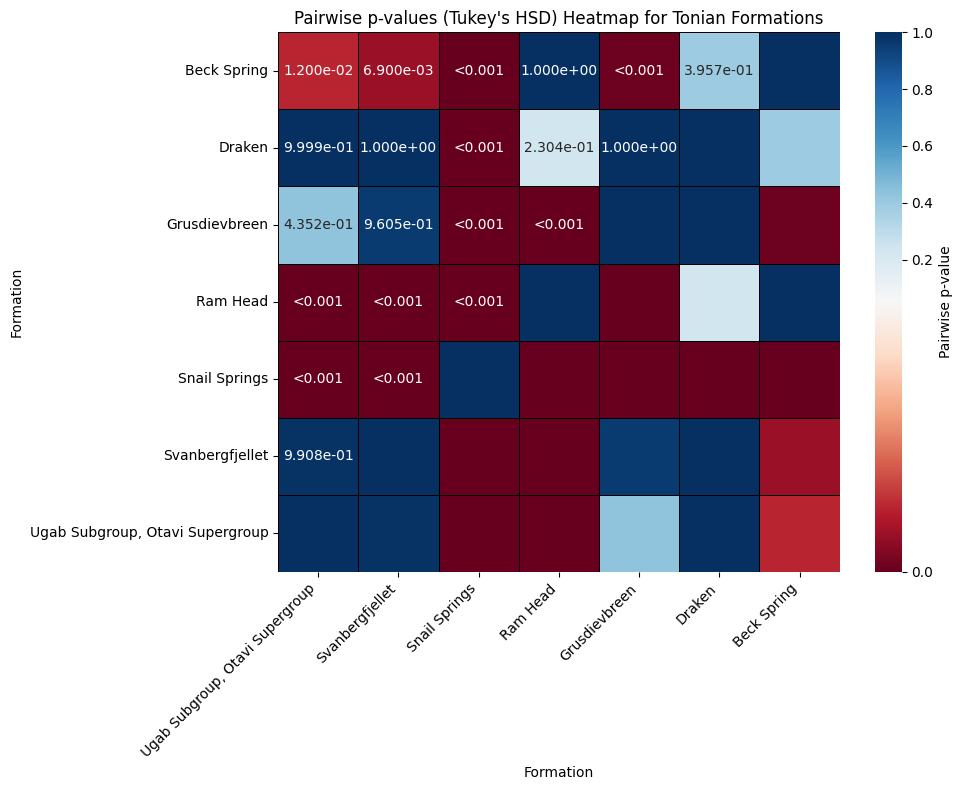


--- Starting analysis for Tonian Locations ---
--- One-Way ANOVA Results for Tonian Locations ---
F-statistic: 56.3689
P-value (ANOVA): 0.0000

ANOVA indicates a significant difference between at least some Tonian location means. Proceeding with Tukey's HSD.
Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Locations_P-values_Heatmap.pdf


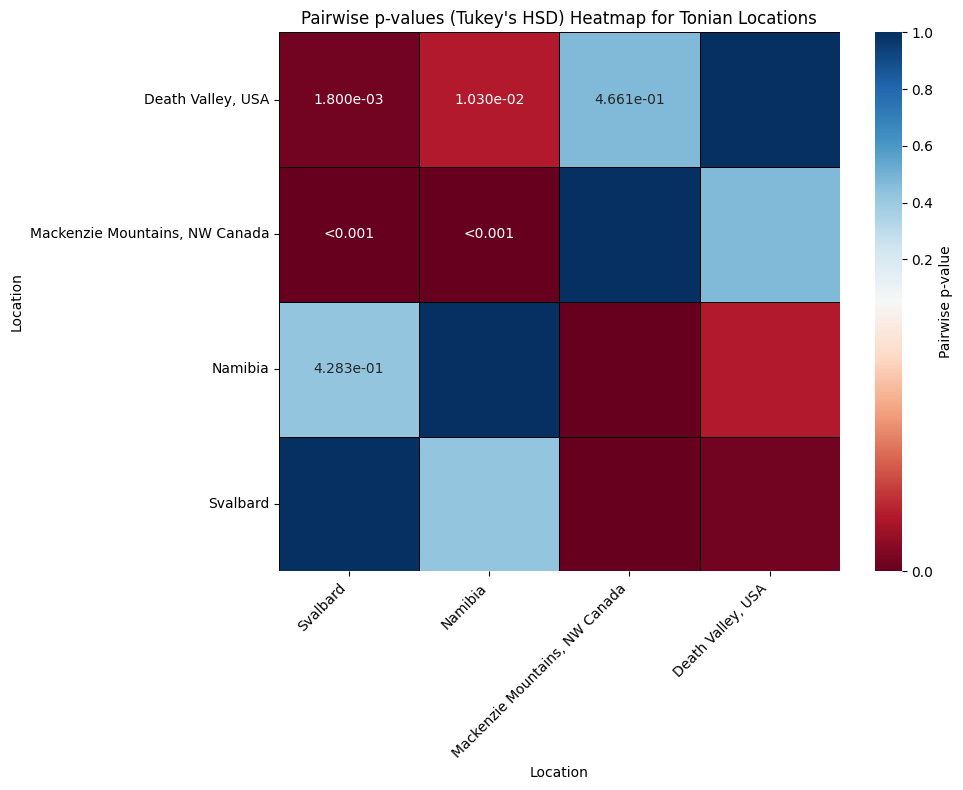

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as colors
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

# --- Step 1: Filter data for Tonian period ---
tonian_df = filtered_df[filtered_df['Period'] == 'Tonian'].copy()

# Ensure 'Total CAP (mmol/mol)' is numeric and handle any non-numeric entries
tonian_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_df['Total CAP (mmol/mol)'], errors='coerce')

# Drop rows where 'Total CAP (mmol/mol)' or 'Formation' is NaN for statistical tests
df_for_stats_tonian_raw = tonian_df.dropna(subset=['Total CAP (mmol/mol)', 'Formation']).copy()

# Identify formations with sufficient data for comparison (at least 2 samples)
formation_counts = df_for_stats_tonian_raw.groupby('Formation')['Total CAP (mmol/mol)'].count()
valid_formation_names = formation_counts[formation_counts >= 2].index.tolist()

# Filter the dataframe to include only these valid formations
df_for_stats_tonian = df_for_stats_tonian_raw[df_for_stats_tonian_raw['Formation'].isin(valid_formation_names)].copy()

# Get unique formations for iteration
unique_formations = sorted(df_for_stats_tonian['Formation'].unique())

# Prepare data for ANOVA
data_groups_tonian = [df_for_stats_tonian['Total CAP (mmol/mol)'][df_for_stats_tonian['Formation'] == f] for f in unique_formations]

# Proceed only if there are enough groups (>=2) and data points for comparison
if len(data_groups_tonian) >= 2 and all(len(g) > 0 for g in data_groups_tonian):
    print("--- One-Way ANOVA Results for Tonian Formations ---")
    f_statistic_tonian, p_value_anova_tonian = stats.f_oneway(*data_groups_tonian)

    print(f"F-statistic: {f_statistic_tonian:.4f}")
    print(f"P-value (ANOVA): {p_value_anova_tonian:.4f}")

    if p_value_anova_tonian < 0.05:
        print("\nANOVA indicates a significant difference between at least some Tonian formation means. Proceeding with Tukey's HSD.")
        # Perform Tukey's HSD post-hoc test
        tukey_results_tonian = pairwise_tukeyhsd(endog=df_for_stats_tonian['Total CAP (mmol/mol)'],
                                                groups=df_for_stats_tonian['Formation'],
                                                alpha=0.05)

        # Convert Tukey's results to a DataFrame
        tukey_df_tonian = pd.DataFrame(data=tukey_results_tonian._results_table.data[1:],
                                    columns=tukey_results_tonian._results_table.data[0])

        p_values_table_tonian = tukey_df_tonian[['group1', 'group2', 'p-adj']].copy()
        p_values_table_tonian.rename(columns={'p-adj': 'p-value'}, inplace=True)

        # --- Create Heatmap for Tonian Formations ---
        all_formations = sorted(list(set(list(p_values_table_tonian['group1'].unique()) + list(p_values_table_tonian['group2'].unique()))))

        p_value_matrix_tonian = pd.DataFrame(1.0, index=all_formations, columns=all_formations)
        p_value_matrix_annot_tonian = pd.DataFrame('', index=all_formations, columns=all_formations, dtype=object)

        for index, row in p_values_table_tonian.iterrows():
            f1 = row['group1']
            f2 = row['group2']
            p_val = row['p-value']

            p_value_matrix_tonian.loc[f1, f2] = p_val
            p_value_matrix_tonian.loc[f2, f1] = p_val # Symmetric

            if p_val < 0.001:
                formatted_p_val = '<0.001'
            else:
                formatted_p_val = f'{p_val:.3e}'

            p_value_matrix_annot_tonian.loc[f1, f2] = formatted_p_val
            p_value_matrix_annot_tonian.loc[f2, f1] = formatted_p_val # Symmetric

        for formation in all_formations:
            p_value_matrix_annot_tonian.loc[formation, formation] = ''

        # Mask the lower triangle of annotations
        for i in range(len(all_formations)):
            for j in range(len(all_formations)):
                if i > j:
                    p_value_matrix_annot_tonian.iloc[i, j] = ''

        # Reverse column order for upper right to lower left diagonal
        p_value_matrix_final_tonian = p_value_matrix_tonian.iloc[:, ::-1].copy()
        p_value_matrix_annot_final_tonian = p_value_matrix_annot_tonian.iloc[:, ::-1].copy()

        plt.figure(figsize=(10, 8)) # Adjusted figure size for potentially more formations
        sns.heatmap(p_value_matrix_final_tonian,
                    annot=p_value_matrix_annot_final_tonian,
                    fmt="",
                    cmap='RdBu',
                    norm=colors.TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=1),
                    linewidths=.5,
                    linecolor='black',
                    cbar_kws={'label': 'Pairwise p-value'})

        plt.title('Pairwise p-values (Tukey\'s HSD) Heatmap for Tonian Formations')
        plt.xlabel('Formation')
        plt.ylabel('Formation')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        output_pdf_path_tonian = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Formations_P-values_Heatmap.pdf"
        plt.savefig(output_pdf_path_tonian)
        print(f"Figure successfully saved to {output_pdf_path_tonian}")
        plt.show()
    else:
        print("\nANOVA does not indicate a significant difference between Tonian formation means (P > 0.05).")
else:
    print("Insufficient data to perform statistical analysis for Tonian formations. Please check the 'Formation' column and 'Total CAP (mmol/mol)' values within the Tonian period.")


# Heatmap for Tonian Locations
print("\n--- Starting analysis for Tonian Locations ---")

# Drop rows where 'Total CAP (mmol/mol)' or 'Location' is NaN for statistical tests
df_for_stats_tonian_locations_raw = tonian_df.dropna(subset=['Total CAP (mmol/mol)', 'Location']).copy()

# Identify locations with sufficient data for comparison (at least 2 samples)
location_counts = df_for_stats_tonian_locations_raw.groupby('Location')['Total CAP (mmol/mol)'].count()
valid_location_names = location_counts[location_counts >= 2].index.tolist()

# Filter the dataframe to include only these valid locations
df_for_stats_tonian_locations = df_for_stats_tonian_locations_raw[df_for_stats_tonian_locations_raw['Location'].isin(valid_location_names)].copy()

# Get unique locations for iteration
unique_locations = sorted(df_for_stats_tonian_locations['Location'].unique())

# Prepare data for ANOVA for locations
data_groups_tonian_locations = [df_for_stats_tonian_locations['Total CAP (mmol/mol)'][df_for_stats_tonian_locations['Location'] == l] for l in unique_locations]

# Proceed only if there are enough groups (>=2) and data points for comparison
if len(data_groups_tonian_locations) >= 2 and all(len(g) > 0 for g in data_groups_tonian_locations):
    print("--- One-Way ANOVA Results for Tonian Locations ---")
    f_statistic_tonian_locations, p_value_anova_tonian_locations = stats.f_oneway(*data_groups_tonian_locations)

    print(f"F-statistic: {f_statistic_tonian_locations:.4f}")
    print(f"P-value (ANOVA): {p_value_anova_tonian_locations:.4f}")

    if p_value_anova_tonian_locations < 0.05:
        print("\nANOVA indicates a significant difference between at least some Tonian location means. Proceeding with Tukey's HSD.")
        # Perform Tukey's HSD post-hoc test for locations
        tukey_results_tonian_locations = pairwise_tukeyhsd(endog=df_for_stats_tonian_locations['Total CAP (mmol/mol)'],
                                                        groups=df_for_stats_tonian_locations['Location'],
                                                        alpha=0.05)

        # Convert Tukey's results to a DataFrame
        tukey_df_tonian_locations = pd.DataFrame(data=tukey_results_tonian_locations._results_table.data[1:],
                                            columns=tukey_results_tonian_locations._results_table.data[0])

        p_values_table_tonian_locations = tukey_df_tonian_locations[['group1', 'group2', 'p-adj']].copy()
        p_values_table_tonian_locations.rename(columns={'p-adj': 'p-value'}, inplace=True)

        # --- Create Heatmap for Tonian Locations ---
        all_locations = sorted(list(set(list(p_values_table_tonian_locations['group1'].unique()) + list(p_values_table_tonian_locations['group2'].unique()))))

        p_value_matrix_tonian_locations = pd.DataFrame(1.0, index=all_locations, columns=all_locations)
        p_value_matrix_annot_tonian_locations = pd.DataFrame('', index=all_locations, columns=all_locations, dtype=object)

        for index, row in p_values_table_tonian_locations.iterrows():
            l1 = row['group1']
            l2 = row['group2']
            p_val_loc = row['p-value']

            p_value_matrix_tonian_locations.loc[l1, l2] = p_val_loc
            p_value_matrix_tonian_locations.loc[l2, l1] = p_val_loc # Symmetric

            if p_val_loc < 0.001:
                formatted_p_val_loc = '<0.001'
            else:
                formatted_p_val_loc = f'{p_val_loc:.3e}'

            p_value_matrix_annot_tonian_locations.loc[l1, l2] = formatted_p_val_loc
            p_value_matrix_annot_tonian_locations.loc[l2, l1] = formatted_p_val_loc # Symmetric

        for location_name in all_locations:
            p_value_matrix_annot_tonian_locations.loc[location_name, location_name] = ''

        # Mask the lower triangle of annotations
        for i in range(len(all_locations)):
            for j in range(len(all_locations)):
                if i > j:
                    p_value_matrix_annot_tonian_locations.iloc[i, j] = ''

        # Reverse column order for upper right to lower left diagonal
        p_value_matrix_final_tonian_locations = p_value_matrix_tonian_locations.iloc[:, ::-1].copy()
        p_value_matrix_annot_final_tonian_locations = p_value_matrix_annot_tonian_locations.iloc[:, ::-1].copy()

        plt.figure(figsize=(10, 8)) # Adjusted figure size
        sns.heatmap(p_value_matrix_final_tonian_locations,
                    annot=p_value_matrix_annot_final_tonian_locations,
                    fmt="",
                    cmap='RdBu',
                    norm=colors.TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=1),
                    linewidths=.5,
                    linecolor='black',
                    cbar_kws={'label': 'Pairwise p-value'})

        plt.title('Pairwise p-values (Tukey\'s HSD) Heatmap for Tonian Locations')
        plt.xlabel('Location')
        plt.ylabel('Location')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        output_pdf_path_tonian_locations = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Locations_P-values_Heatmap.pdf"
        plt.savefig(output_pdf_path_tonian_locations)
        print(f"Figure successfully saved to {output_pdf_path_tonian_locations}")
        plt.show()
    else:
        print("\nANOVA does not indicate a significant difference between Tonian location means (P > 0.05).")
else:
    print("Insufficient data to perform statistical analysis for Tonian locations. Please check the 'Location' column and 'Total CAP (mmol/mol)' values within the Tonian period.")


In [ ]:
print("Summary Statistics for 'Total CAP (mmol/mol)' by Tonian Formation:")
if 'df_for_stats_tonian' in locals() and not df_for_stats_tonian.empty:
    summary_stats_tonian = df_for_stats_tonian.groupby('Formation')['Total CAP (mmol/mol)'].describe()
    display(summary_stats_tonian)
else:
    print("Error: df_for_stats_tonian DataFrame not found or is empty.")

Summary Statistics for 'Total CAP (mmol/mol)' by Tonian Formation:


,count,mean,std,min,25%,50%,75%,max
Formation,,,,,,,,
Beck Spring,9.0,0.266889,0.151789,0.047000,0.214000,0.253000,0.301000,0.589000
Draken,3.0,0.115848,0.031212,0.096247,0.097852,0.099456,0.125649,0.151841
Grusdievbreen,66.0,0.103725,0.093494,0.001226,0.037047,0.066694,0.145742,0.369324
Ram Head,57.0,0.269979,0.185285,0.010184,0.093717,0.278410,0.382588,0.698804
Snail Springs,16.0,0.542403,0.162371,0.248310,0.436742,0.553231,0.673272,0.754183
Svanbergfjellet,56.0,0.123324,0.076956,0.017963,0.065432,0.118194,0.166999,0.335841
"Ugab Subgroup, Otavi Supergroup",156.0,0.135975,0.081248,0.003835,0.074217,0.121859,0.181260,0.527237


In [ ]:
output_excel_path_tonian_summary = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Formations_Summary_Stats.xlsx"
if 'summary_stats_tonian' in locals() and not summary_stats_tonian.empty:
    summary_stats_tonian.to_excel(output_excel_path_tonian_summary)
    print(f"Summary statistics successfully saved to {output_excel_path_tonian_summary}")
else:
    print("Error: summary_stats_tonian DataFrame not found or is empty. Please ensure the summary statistics cell (f792d31f) has been run.")

Summary statistics successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Formations_Summary_Stats.xlsx


In [ ]:
import seaborn as sns

# 1. Define the new desired order for the periods on the plot
plot_period_order = ['Neoarchean','Paleoproterozoic', 'Mid-Proterozoic', 'Neoproterozoic', 'Phanerozoic']

# 2. Create a new color palette
# The number of colors should match the number of periods in plot_period_order
plot_palette_colors = sns.color_palette("viridis", n_colors=len(plot_period_order))

# 3. Create a dictionary to map period names to colors for consistent coloring
plot_period_color_map = {period: color for period, color in zip(plot_period_order, plot_palette_colors)}

print("Defined plot_period_order:", plot_period_order)
print("Generated plot_period_color_map:", plot_period_color_map)

Defined plot_period_order: ['Neoarchean', 'Paleoproterozoic', 'Mid-Proterozoic', 'Neoproterozoic', 'Phanerozoic']
Generated plot_period_color_map: {'Neoarchean': (0.267968, 0.223549, 0.512008), 'Paleoproterozoic': (0.190631, 0.407061, 0.556089), 'Mid-Proterozoic': (0.127568, 0.566949, 0.550556), 'Neoproterozoic': (0.20803, 0.718701, 0.472873), 'Phanerozoic': (0.565498, 0.84243, 0.262877)}


In [ ]:
import pandas as pd

# 1. Make a copy of the filtered_df DataFrame
df_for_comprehensive_plot = filtered_df.copy()

# 2. Filter filtered_df to select only the rows for Neoproterozoic grouping
neoproterozoic_periods = ['Tonian', 'Ediacaran']
neoprooproterozoic_raw_data = filtered_df[filtered_df['Period'].isin(neoproterozoic_periods)].copy()

# 3. Create a new DataFrame for the Neoproterozoic grouped data and update its 'Period' column
neoproterozoic_grouped_data = neoprooproterozoic_raw_data.copy()
neoproterozoic_grouped_data['Period'] = 'Neoproterozoic'

# 4. Concatenate df_for_comprehensive_plot with the new Neoproterozoic grouped data
df_for_comprehensive_plot = pd.concat([df_for_comprehensive_plot, neoproterozoic_grouped_data], ignore_index=True)

# 5. Ensure 'Total CAP (mmol/mol)' is numeric and drop NaN rows
df_for_comprehensive_plot['Total CAP (mmol/mol)'] = pd.to_numeric(df_for_comprehensive_plot['Total CAP (mmol/mol)'], errors='coerce')
df_for_comprehensive_plot.dropna(subset=['Total CAP (mmol/mol)'], inplace=True)

print("Created df_for_comprehensive_plot with original periods and an additional 'Neoproterozoic' category.")
print("Unique Periods in df_for_comprehensive_plot:")
print(df_for_comprehensive_plot['Period'].unique())

Created df_for_comprehensive_plot with original periods and an additional 'Neoproterozoic' category.
Unique Periods in df_for_comprehensive_plot:
['Neoarchean' 'Paleoproterozoic' 'Mid-Proterozoic' 'Tonian' 'Ediacaran'
 'Paleozoic' 'Cenozoic' 'Neoproterozoic']


In [ ]:
import seaborn as sns

# 1. Define a list named plot_period_order with the specified sequence
plot_period_order = ['Neoarchean','Paleoproterozoic','Mid-Proterozoic', 'Neoproterozoic', 'Tonian', 'Ediacaran', 'Cenozoic']

# 2. Generate a color palette
plot_palette_colors = sns.color_palette("viridis", n_colors=len(plot_period_order))

# 3. Create a dictionary to map period names to colors
plot_period_color_map = {period: color for period, color in zip(plot_period_order, plot_palette_colors)}

print("Defined plot_period_order:", plot_period_order)
print("Generated plot_period_color_map:", plot_period_color_map)

Defined plot_period_order: ['Neoarchean', 'Paleoproterozoic', 'Mid-Proterozoic', 'Neoproterozoic', 'Tonian', 'Ediacaran', 'Cenozoic']
Generated plot_period_color_map: {'Neoarchean': (0.278826, 0.17549, 0.483397), 'Paleoproterozoic': (0.229739, 0.322361, 0.545706), 'Mid-Proterozoic': (0.172719, 0.448791, 0.557885), 'Neoproterozoic': (0.127568, 0.566949, 0.550556), 'Tonian': (0.157851, 0.683765, 0.501686), 'Ediacaran': (0.369214, 0.788888, 0.382914), 'Cenozoic': (0.678489, 0.863742, 0.189503)}


# Task
Perform One-Way ANOVA and Tukey's HSD post-hoc test on 'Total CAP (mmol/mol)' across all geological periods in `filtered_df`, including 'Ediacaran'. Display the generated pairwise p-values table, highlighting statistically significant p-values (p < 0.05).

## Perform Statistical Analysis for All Periods


Perform One-Way ANOVA and Wilcoxon rank-sum tests (because non-normal distribution) on 'Total CAP (mmol/mol)' across all geological periods.


In [ ]:

import scipy.stats as stats
import pandas as pd
from statsmodels.stats.multitest import multipletests
import itertools
import numpy as np # Import numpy for effect size calculation

# 1. Ensure the 'Total CAP (mmol/mol)' column is numeric and drop rows with NaN
df_for_stats_all_periods = filtered_df.copy()
df_for_stats_all_periods['Total CAP (mmol/mol)'] = pd.to_numeric(df_for_stats_all_periods['Total CAP (mmol/mol)'], errors='coerce')
df_for_stats_all_periods.dropna(subset=['Total CAP (mmol/mol)', 'Period'], inplace=True)

# Exclude Mackenzie Mountains data from Tonian and Ediacaran periods
mackenzie_location = 'Mackenzie Mountains, NW Canada'
neoproterozoic_periods = ['Tonian', 'Ediacaran']

df_for_stats_all_periods = df_for_stats_all_periods[
    ~((df_for_stats_all_periods['Period'].isin(neoproterozoic_periods)) &
      (df_for_stats_all_periods['Location'] == mackenzie_location))
].copy()

# 2. Get unique periods for pairwise comparisons
unique_periods = df_for_stats_all_periods['Period'].unique()

# 3. Perform pairwise Wilcoxon rank-sum tests
pairwise_results = []

# Use itertools.combinations to get all unique pairs of periods
for period1, period2 in itertools.combinations(unique_periods, 2):
    data1 = df_for_stats_all_periods['Total CAP (mmol/mol)'][(df_for_stats_all_periods['Period'] == period1)].dropna()
    data2 = df_for_stats_all_periods['Total CAP (mmol/mol)'][(df_for_stats_all_periods['Period'] == period2)].dropna()

    # Only perform test if both groups have enough data points (at least 2 for ranksums)
    if len(data1) >= 2 and len(data2) >= 2:
        stat, p_value = stats.ranksums(data1, data2)
        n_total = len(data1) + len(data2) # Calculate N for effect size
        pair = (period1, period2)
        pairwise_results.append({'group1': period1, 'group2': period2, 'statistic': stat, 'raw_p_value': p_value, 'n_total': n_total})

if not pairwise_results:
    print("Insufficient data to perform any pairwise Wilcoxon rank-sum tests.")
else:
    pairwise_df = pd.DataFrame(pairwise_results)

    # 4. Apply Benjamini-Hochberg p-value correction
    reject, p_values_corrected, alpha_sidak, alpha_bonferroni = multipletests(pairwise_df['raw_p_value'], alpha=0.05, method='fdr_bh')

    pairwise_df['corrected_p_value'] = p_values_corrected
    pairwise_df['significant_bh'] = reject

    # Calculate effect size 'r' using the z-statistic and total N
    # Effect size r = Z / sqrt(N)
    pairwise_df['effect_size_r'] = pairwise_df['statistic'] / np.sqrt(pairwise_df['n_total'])

    print("--- Pairwise Wilcoxon Rank-Sum Test Results with Benjamini-Hochberg Correction ---")
    display(pairwise_df[['group1', 'group2', 'raw_p_value', 'corrected_p_value', 'significant_bh', 'effect_size_r']])

    # You can also print a summary of significant pairs
    significant_pairs = pairwise_df[pairwise_df['significant_bh']]
    if not significant_pairs.empty:
        print("\nSignificant pairs (after Benjamini-Hochberg correction):")
        for index, row in significant_pairs.iterrows():
            print(f"  {row['group1']} vs. {row['group2']} (p_corrected = {row['corrected_p_value']:.4f}, r = {row['effect_size_r']:.2f})")
    else:
        print("\nNo statistically significant pairs found after Benjamini-Hochberg correction.")

    # Save the pairwise_df to an Excel file
    output_excel_path_pairwise_wilcoxon = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Pairwise_Wilcoxon_Results_BH_Corrected.xlsx"
    pairwise_df.to_excel(output_excel_path_pairwise_wilcoxon, index=False)
    print(f"\nPairwise Wilcoxon test results successfully saved to {output_excel_path_pairwise_wilcoxon}")

--- Pairwise Wilcoxon Rank-Sum Test Results with Benjamini-Hochberg Correction ---


,group1,group2,raw_p_value,corrected_p_value,significant_bh,effect_size_r
0,Neoarchean,Paleoproterozoic,6.284660e-18,1.885398e-17,True,0.446702
1,Neoarchean,Mid-Proterozoic,6.533739e-03,7.622696e-03,True,0.178175
2,Neoarchean,Tonian,8.226960e-01,8.638308e-01,False,-0.011232
3,Neoarchean,Ediacaran,8.014575e-03,8.858214e-03,True,-0.099298
4,Neoarchean,Paleozoic,4.800494e-07,7.754644e-07,True,0.423949
5,Neoarchean,Cenozoic,1.635325e-30,5.723637e-30,True,0.512442
6,Paleoproterozoic,Mid-Proterozoic,6.858132e-16,1.800260e-15,True,-0.407749
7,Paleoproterozoic,Tonian,1.362059e-33,7.150809e-33,True,-0.511808
8,Paleoproterozoic,Ediacaran,1.574174e-61,1.101922e-60,True,-0.560488
9,Paleoproterozoic,Paleozoic,9.815744e-01,9.815744e-01,False,-0.001333



Significant pairs (after Benjamini-Hochberg correction):
  Neoarchean vs. Paleoproterozoic (p_corrected = 0.0000, r = 0.45)
  Neoarchean vs. Mid-Proterozoic (p_corrected = 0.0076, r = 0.18)
  Neoarchean vs. Ediacaran (p_corrected = 0.0089, r = -0.10)
  Neoarchean vs. Paleozoic (p_corrected = 0.0000, r = 0.42)
  Neoarchean vs. Cenozoic (p_corrected = 0.0000, r = 0.51)
  Paleoproterozoic vs. Mid-Proterozoic (p_corrected = 0.0000, r = -0.41)
  Paleoproterozoic vs. Tonian (p_corrected = 0.0000, r = -0.51)
  Paleoproterozoic vs. Ediacaran (p_corrected = 0.0000, r = -0.56)
  Paleoproterozoic vs. Cenozoic (p_corrected = 0.0000, r = 0.24)
  Mid-Proterozoic vs. Tonian (p_corrected = 0.0010, r = -0.17)
  Mid-Proterozoic vs. Ediacaran (p_corrected = 0.0000, r = -0.25)
  Mid-Proterozoic vs. Paleozoic (p_corrected = 0.0000, r = 0.34)
  Mid-Proterozoic vs. Cenozoic (p_corrected = 0.0000, r = 0.52)
  Tonian vs. Ediacaran (p_corrected = 0.0004, r = -0.12)
  Tonian vs. Paleozoic (p_corrected = 0.0000,

Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Pairwise_Wilcoxon_Effect_Size_Heatmap_BH_Corrected.pdf


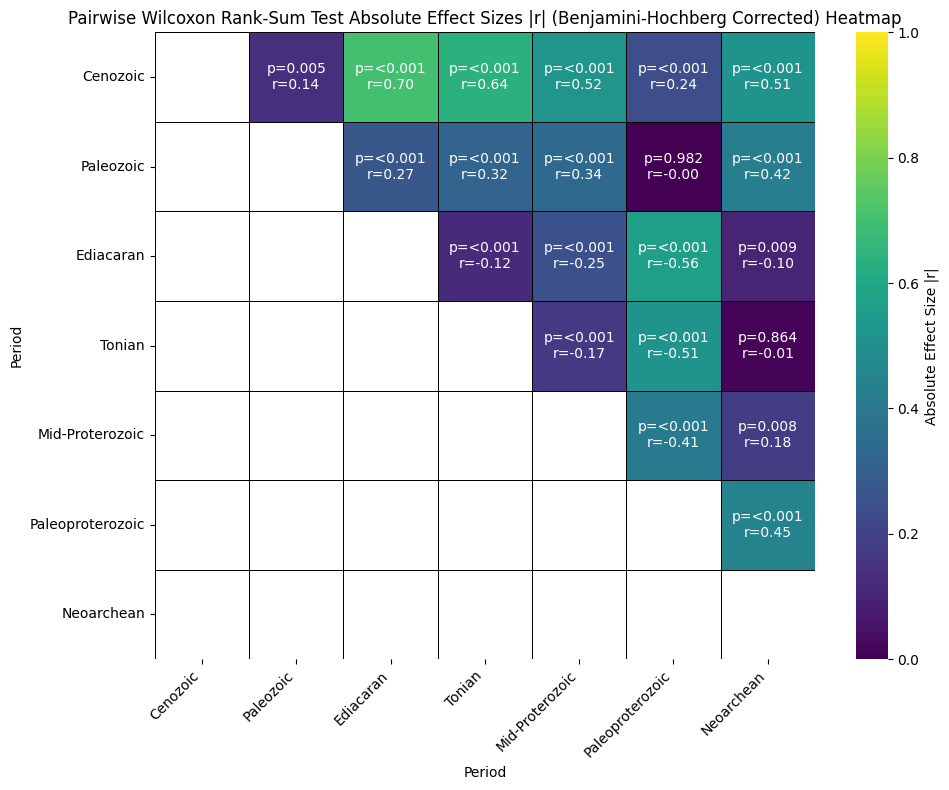

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as colors

# 1. Define the desired order for the periods on both axes of the heatmap
all_periods_for_heatmap_wilcoxon = [
    'Cenozoic', 'Paleozoic', 'Ediacaran', 'Tonian', 'Mid-Proterozoic', 'Paleoproterozoic', 'Neoarchean'
]

# 2. Create an empty DataFrame for the absolute effect sizes, initialized with 0.0
# This matrix will be used for coloring the heatmap
effect_size_matrix_wilcoxon = pd.DataFrame(0.0, index=all_periods_for_heatmap_wilcoxon, columns=all_periods_for_heatmap_wilcoxon)

# We still need p_value_matrix for annotation logic, initialize it
p_value_matrix_wilcoxon = pd.DataFrame(1.0, index=all_periods_for_heatmap_wilcoxon, columns=all_periods_for_heatmap_wilcoxon)

# 3. Create another empty DataFrame for annotations, initialized with empty strings
p_value_matrix_annot_wilcoxon = pd.DataFrame('', index=all_periods_for_heatmap_wilcoxon, columns=all_periods_for_heatmap_wilcoxon, dtype=object)

# Populate the matrices with corrected_p_value and effect_size_r from pairwise_df
for index, row in pairwise_df.iterrows():
    g1 = row['group1']
    g2 = row['group2']
    p_val_corrected = row['corrected_p_value']
    effect_size_r = row['effect_size_r']

    # Assign the absolute effect size to both (group1, group2) and (group2, g1) cells
    effect_size_matrix_wilcoxon.loc[g1, g2] = abs(effect_size_r)
    effect_size_matrix_wilcoxon.loc[g2, g1] = abs(effect_size_r) # Symmetric

    # Assign the corrected p-value for potential future use or to keep consistency if needed
    p_value_matrix_wilcoxon.loc[g1, g2] = p_val_corrected
    p_value_matrix_wilcoxon.loc[g2, g1] = p_val_corrected # Symmetric

    # Format the p-value
    if p_val_corrected < 0.001:
        formatted_p_val = '<0.001'
    else:
        formatted_p_val = f'{p_val_corrected:.3f}' # Format to 3 decimal places

    # Format the effect size and combine with p-value
    formatted_effect_size = f'r={effect_size_r:.2f}'
    combined_annotation = f'p={formatted_p_val}\n{formatted_effect_size}' # Use \n for newline

    # Assign the formatted string to both (group1, group2) and (group2, g1) cells
    p_value_matrix_annot_wilcoxon.loc[g1, g2] = combined_annotation
    p_value_matrix_annot_wilcoxon.loc[g2, g1] = combined_annotation # Symmetric

# 4. Set the diagonal elements of effect_size_matrix_wilcoxon to NaN for no coloring
for period in all_periods_for_heatmap_wilcoxon:
    effect_size_matrix_wilcoxon.loc[period, period] = np.nan
    p_value_matrix_annot_wilcoxon.loc[period, period] = '' # Keep annotation empty on diagonal

# 5. Set all elements in the lower triangle of both matrices to NaN/empty for clearer visualization (only show upper triangle)
for i in range(len(all_periods_for_heatmap_wilcoxon)):
    for j in range(len(all_periods_for_heatmap_wilcoxon)):
        if i > j:
            effect_size_matrix_wilcoxon.iloc[i, j] = np.nan # No coloring in lower triangle
            p_value_matrix_annot_wilcoxon.iloc[i, j] = '' # No annotation in lower triangle

# The matrices are already in the desired order, so no need to reverse columns
effect_size_matrix_final_wilcoxon = effect_size_matrix_wilcoxon
p_value_matrix_annot_final_wilcoxon = p_value_matrix_annot_wilcoxon

# 6. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(effect_size_matrix_final_wilcoxon,
            annot=p_value_matrix_annot_final_wilcoxon,
            fmt="", # Use empty format string as annotations are already formatted
            cmap='viridis', # Changed colormap to sequential for magnitude
            norm=colors.Normalize(vmin=0, vmax=1), # Norm should be from 0 to 1 for absolute effect size
            linewidths=.5,
            linecolor='black',
            cbar_kws={'label': 'Absolute Effect Size |r|'})

plt.title('Pairwise Wilcoxon Rank-Sum Test Absolute Effect Sizes |r| (Benjamini-Hochberg Corrected) Heatmap')
plt.xlabel('Period')
plt.ylabel('Period')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the figure as a PDF
output_pdf_path_wilcoxon_heatmap = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Pairwise_Wilcoxon_Effect_Size_Heatmap_BH_Corrected.pdf"
plt.savefig(output_pdf_path_wilcoxon_heatmap)
print(f"Figure successfully saved to {output_pdf_path_wilcoxon_heatmap}")
plt.show()

### Summary Statistics for Total CAP (mmol/mol) by Period

This section provides descriptive statistics (count, mean, standard deviation, min, 25th percentile, 50th percentile (median), 75th percentile, and max) for the 'Total CAP (mmol/mol)' for each geological period present in the `new_combined_df`.

In [ ]:
print("Summary Statistics for 'Total CAP (mmol/mol)' by Geological Period (Tonian excluding Mackenzie Mountains):")

# Ensure 'Total CAP (mmol/mol)' is numeric and drop rows with NaN values for calculation
df_for_summary = filtered_df.copy() #
df_for_summary['Total CAP (mmol/mol)'] = pd.to_numeric(df_for_summary['Total CAP (mmol/mol)'], errors='coerce')
df_for_summary.dropna(subset=['Total CAP (mmol/mol)', 'Period'], inplace=True)

# Calculate initial summary statistics for all periods
summary_stats_filtered_periods = df_for_summary.groupby('Period')['Total CAP (mmol/mol)'].describe()

# --- Custom modification for Tonian excluding Mackenzie Mountains ---
# Filter for Tonian period
tonian_data = df_for_summary[df_for_summary['Period'] == 'Tonian'].copy()

# Filter out 'Mackenzie Mountains, NW Canada' from Tonian data
tonian_data_no_mackenzie = tonian_data[tonian_data['Location'] != 'Mackenzie Mountains, NW Canada'].copy()

# Calculate summary statistics for the filtered Tonian data
if not tonian_data_no_mackenzie.empty:
    tonian_summary_no_mackenzie = tonian_data_no_mackenzie['Total CAP (mmol/mol)'].describe()
    # Update the 'Tonian' row in the main summary_stats_filtered_periods DataFrame
    summary_stats_filtered_periods.loc['Tonian'] = tonian_summary_no_mackenzie
else:
    print("Warning: No Tonian data found after excluding Mackenzie Mountains to update summary statistics.")

# Display the updated summary statistics
display(summary_stats_filtered_periods)

# Define the output path for the Excel file
output_excel_path_summary_stats = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Summary_Statistics_by_Geological_Period.xlsx"

# Save the summary statistics to an Excel file
summary_stats_filtered_periods.to_excel(output_excel_path_summary_stats)
print(f"Summary statistics successfully saved to {output_excel_path_summary_stats}")

Summary Statistics for 'Total CAP (mmol/mol)' by Geological Period (Tonian excluding Mackenzie Mountains):


,count,mean,std,min,25%,50%,75%,max
Period,,,,,,,,
Cenozoic,395.0,0.035254,0.035072,0.002600,0.011000,0.021319,0.050394,0.219190
Ediacaran,606.0,0.170543,0.180911,0.000000,0.090000,0.134500,0.200000,2.180000
Mid-Proterozoic,126.0,0.096930,0.058806,0.015633,0.057197,0.085494,0.125422,0.328557
Neoarchean,107.0,0.129488,0.096862,0.002000,0.066000,0.113000,0.164000,0.612000
Paleoproterozoic,266.0,0.054339,0.052210,0.003000,0.018000,0.039000,0.073000,0.408000
Paleozoic,34.0,0.053824,0.049053,0.010000,0.020000,0.025000,0.087500,0.180000
Tonian,291.0,0.130410,0.089777,0.001226,0.061381,0.111631,0.180010,0.589000


Summary statistics successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Summary_Statistics_by_Geological_Period.xlsx


In [ ]:
total_counts = summary_stats_filtered_periods['count'].sum()
print(f"Sum of counts in summary_stats_filtered_periods: {total_counts}")
print(f"Number of rows in filtered_df: {filtered_df.shape[0]}")

Sum of counts in summary_stats_filtered_periods: 1825.0
Number of rows in filtered_df: 1898


## Generate Ridge Density Diagram

Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Total_CAP_Ridge_Plot_LogScale_Phanerozoic_NoMackenzieNeoproterozoic.pdf


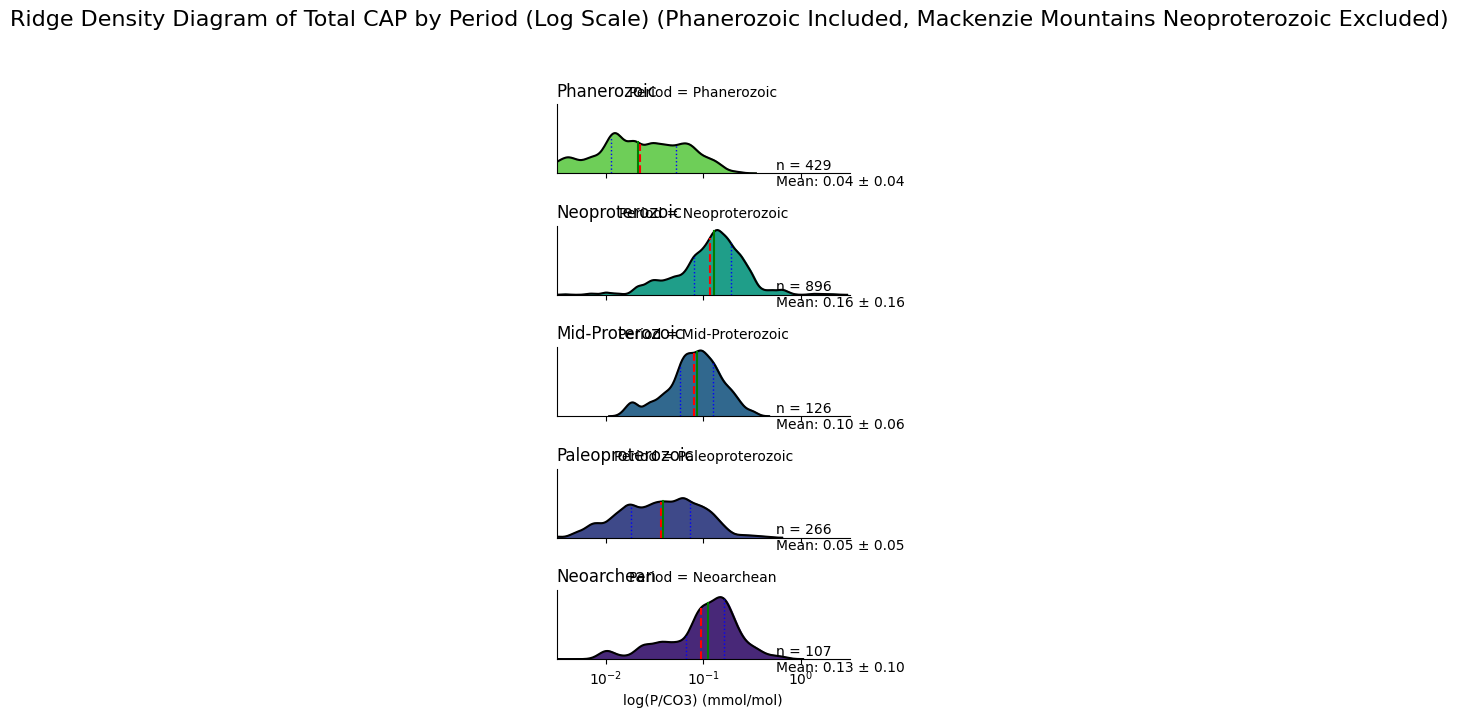

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for log transformation
from scipy import stats # Import for gaussian_kde

# Create a copy to avoid modifying the original DataFrame used elsewhere
temp_ridge_plot_df = df_for_comprehensive_plot.copy()

# Combine Paleozoic and Cenozoic into 'Phanerozoic'
temp_ridge_plot_df.loc[temp_ridge_plot_df['Period'].isin(['Paleozoic', 'Cenozoic']), 'Period'] = 'Phanerozoic'

# Filter temp_ridge_plot_df for the desired periods
desired_periods_for_ridge = ['Neoarchean', 'Paleoproterozoic', 'Mid-Proterozoic', 'Neoproterozoic', 'Phanerozoic']
ridge_plot_df = temp_ridge_plot_df[temp_ridge_plot_df['Period'].isin(desired_periods_for_ridge)].copy()

# Exclude Mackenzie Mountains data from the Neoproterozoic period for the ridge plot
ridge_plot_df = ridge_plot_df[
    ~((ridge_plot_df['Period'] == 'Neoproterozoic') & (ridge_plot_df['Location'] == 'Mackenzie Mountains, NW Canada'))
].copy()


# Ensure 'Total CAP (mmol/mol)' is numeric and drop NaNs
ridge_plot_df['Total CAP (mmol/mol)'] = pd.to_numeric(ridge_plot_df['Total CAP (mmol/mol)'], errors='coerce')
ridge_plot_df.dropna(subset=['Total CAP (mmol/mol)'], inplace=True);

# Filter out zero or negative values for log transformation and create a log-transformed column
ridge_plot_df_log = ridge_plot_df[ridge_plot_df['Total CAP (mmol/mol)'] > 0].copy()
ridge_plot_df_log['log_total_cap'] = np.log10(ridge_plot_df_log['Total CAP (mmol/mol)'])

# --- Calculate statistics for vertical lines (on log scale) and annotations (on original scale) ---
period_stats_for_lines = ridge_plot_df_log.groupby('Period')['log_total_cap'].agg(
    mean='mean',
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index()

# Calculate statistics for annotations (original CAP values)
period_stats_for_annotations = ridge_plot_df_log.groupby('Period')['Total CAP (mmol/mol)'].agg(
    mean='mean',
    std='std'
).reset_index()


# Define the order for plotting (reversed vertically as requested)
plot_order_ridge = ['Phanerozoic', 'Neoproterozoic', 'Mid-Proterozoic', 'Paleoproterozoic', 'Neoarchean']

# Ensure 'Phanerozoic' has a color in universal_color_map
# Using the color of 'Paleozoic' for 'Phanerozoic' for consistency
if 'Paleozoic' in universal_color_map and 'Phanerozoic' not in universal_color_map:
    universal_color_map['Phanerozoic'] = universal_color_map['Paleozoic']
elif 'Phanerozoic' not in universal_color_map: # Fallback if Paleozoic isn't there or other edge cases
     universal_color_map['Phanerozoic'] = (0.5, 0.5, 0.5) # Assign a default grey color

# Use the global universal_color_map for consistency, filtering for periods actually in plot_order_ridge
ridge_color_map = {period: universal_color_map[period] for period in plot_order_ridge if period in universal_color_map}

# Set up the FacetGrid for ridge plot
g = sns.FacetGrid(ridge_plot_df_log, row='Period', hue='Period', aspect=2.5, height=1.5,
                  palette=ridge_color_map, row_order=plot_order_ridge)

# Draw the densities - adjusted bw_adjust
g.map(sns.kdeplot, 'log_total_cap', fill=True, alpha=1, linewidth=1.5, bw_adjust=0.5)
g.map(sns.kdeplot, 'log_total_cap', color='black', bw_adjust=0.5)

# Set the x-axis label
g.set_xlabels('log(P/CO3) (mmol/mol)')

# Remove y-axis labels and ticks for cleaner look
g.set(ylabel="", yticks=[])

# Adjust subplot params for a tight layout
g.fig.subplots_adjust(hspace=-0.5)

# Calculate counts for annotations based on the filtered data
counts_for_ridge_plot = ridge_plot_df_log.groupby('Period')['Total CAP (mmol/mol)'].count().reset_index(name='Count')


# Add titles to each row dynamically and vertical lines for stats
for i, ax in enumerate(g.axes.flat):
    period_name = plot_order_ridge[i]

    # Check if the period has statistics before trying to access them
    stats_row_lines_df = period_stats_for_lines[period_stats_for_lines['Period'] == period_name]
    stats_row_anno_df = period_stats_for_annotations[period_stats_for_annotations['Period'] == period_name]
    count_row_df = counts_for_ridge_plot[counts_for_ridge_plot['Period'] == period_name]

    if not stats_row_lines_df.empty and not stats_row_anno_df.empty and not count_row_df.empty:
        stats_row_lines = stats_row_lines_df.iloc[0]
        stats_row_anno = stats_row_anno_df.iloc[0]
        count = count_row_df['Count'].iloc[0]

        mean_cap_anno = stats_row_anno['mean']
        std_cap_anno = stats_row_anno['std']

        # --- Add 'n=' and Mean +/- Std annotations ---
        annotation_text = f'n = {count}\nMean: {mean_cap_anno:.2f} \u00b1 {std_cap_anno:.2f}'

        # Place the annotation on the right side of the x-axis level
        # Adjust y-position slightly to allow space for two lines
        ax.text(ax.get_xlim()[1] + 0.1, 0, annotation_text, va='center', ha='left', fontsize=10, transform=ax.get_yaxis_transform())

        # --- Add vertical lines for mean, median, q25, q75 (on log scale) ---
        # Get KDE data from the plotted line for interpolation
        if len(ax.lines) > 0:
            x_kde, y_kde = ax.lines[0].get_data() # Get data from the first KDE line
            if len(x_kde) > 1 and len(y_kde) > 1:
                # Function to get density at a given x-value from KDE data
                def get_density_at_x(x_val, x_kde, y_kde):
                    # Handle cases where x_val is outside x_kde range to avoid issues with interp
                    if x_val < x_kde.min(): return y_kde.min()
                    if x_val > x_kde.max(): return y_kde.min() # Returning min density if outside range
                    return np.interp(x_val, x_kde, y_kde)

                mean_y_density = get_density_at_x(stats_row_lines['mean'], x_kde, y_kde)
                median_y_density = get_density_at_x(stats_row_lines['median'], x_kde, y_kde)
                q25_y_density = get_density_at_x(stats_row_lines['q25'], x_kde, y_kde)
                q75_y_density = get_density_at_x(stats_row_lines['q75'], x_kde, y_kde)

                ax.plot([stats_row_lines['mean'], stats_row_lines['mean']], [0, mean_y_density], color='red', linestyle='--', linewidth=1.5, zorder=3)
                ax.plot([stats_row_lines['median'], stats_row_lines['median']], [0, median_y_density], color='green', linestyle='-', linewidth=1.5, zorder=3) # Median line
                ax.plot([stats_row_lines['q25'], stats_row_lines['q25']], [0, q25_y_density], color='blue', linestyle=':', linewidth=1.0, zorder=3)
                ax.plot([stats_row_lines['q75'], stats_row_lines['q75']], [0, q75_y_density], color='blue', linestyle=':', linewidth=1.0, zorder=3)
    else:
        # If no data for log plot for this period, add just a message
        ax.text(ax.get_xlim()[1] + 0.1, 0, "No valid CAP > 0 data", va='center', ha='left', fontsize=10, transform=ax.get_yaxis_transform(), color='gray')

    # Re-add the default FacetGrid title for each subplot (Period labels)
    ax.set_title(period_name, loc='left', fontsize=12)

    # Add legend to the first subplot only to avoid repetition, if desired (optional, may clutter)
    # if i == 0:
    #     ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Set overall title for the figure
g.fig.suptitle('Ridge Density Diagram of Total CAP by Period (Log Scale) (Phanerozoic Included, Mackenzie Mountains Neoproterozoic Excluded)',
               ha='center', fontsize=16, x=0.5, y=0.98)

# Set a consistent x-axis limit for all plots and custom ticks for log scale
# Determine appropriate log ticks based on data range. Max value is 3.05, so log10(3.05) is ~0.48
# Smallest non-zero value (from earlier describe) is >0, assume effectively 0.01 (log10=-2) or 0.001 (log10=-3) if data allows.
# For this dataset, let's use a range covering up to 1.0 (log10=0) and below
log_ticks = [-2, -1, 0] # Corresponds to 0.01, 0.1, 1.0
log_labels = [f'$10^{{{int(t)}}}$' for t in log_ticks] # Formats as 10^-2, 10^-1, 10^0

g.set(xlim=(-2.5, 0.5), xticks=log_ticks, xticklabels=log_labels) # Adjust xlim to encompass data roughly from 10^-2.5 to 10^0.5

# Invert y-axis to have earliest period at the top, if desired (optional)
#g.invert_yaxis()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle

# Save the figure as a PDF with a new name for the log scale plot
output_pdf_path_ridge = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Total_CAP_Ridge_Plot_LogScale_Phanerozoic_NoMackenzieNeoproterozoic.pdf"
plt.savefig(output_pdf_path_ridge)
print(f"Figure successfully saved to {output_pdf_path_ridge}")

plt.show()

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# 1. Create a new DataFrame by filtering filtered_df for Neoproterozoic periods
neoproterozoic_periods = ['Tonian', 'Ediacaran']
ridge_plot_neoproterozoic_df = filtered_df[filtered_df['Period'].isin(neoproterozoic_periods)].copy()

# EXCLUDE MACKENZIE MOUNTAINS SAMPLES
ridge_plot_neoproterozoic_df = ridge_plot_neoproterozoic_df[
    ridge_plot_neoproterozoic_df['Location'] != 'Mackenzie Mountains, NW Canada'
].copy()

# 2. Convert 'Total CAP (mmol/mol)' to numeric, coercing errors
ridge_plot_neoproterozoic_df['Total CAP (mmol/mol)'] = pd.to_numeric(ridge_plot_neoproterozoic_df['Total CAP (mmol/mol)'], errors='coerce')

# 3. Drop rows with NaN values in 'Total CAP (mmol/mol)'
ridge_plot_neoproterozoic_df.dropna(subset=['Total CAP (mmol/mol)'], inplace=True);

# 4. Filter to include only rows where 'Total CAP (mmol/mol)' is greater than 0
ridge_plot_neoproterozoic_df = ridge_plot_neoproterozoic_df[ridge_plot_neoproterozoic_df['Total CAP (mmol/mol)'] > 0].copy()

# 5. Create a new column 'log_total_cap' with log10 transformation
ridge_plot_neoproterozoic_df['log_total_cap'] = np.log10(ridge_plot_neoproterozoic_df['Total CAP (mmol/mol)'])

# 6. Group by 'Period' and calculate mean, Q1, and Q3 of 'log_total_cap' (and std)
neoproterozoic_period_stats_log = ridge_plot_neoproterozoic_df.groupby('Period')['log_total_cap'].agg(
    mean='mean',
    median='median', # Added median here
    std='std', # Added std
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index()

# Calculate statistics for annotations (original CAP values)
neoproterozoic_period_stats_for_annotations = ridge_plot_neoproterozoic_df.groupby('Period')['Total CAP (mmol/mol)'].agg(
    mean='mean',
    std='std'
).reset_index()


print("Ridge plot Neoproterozoic DataFrame head:")
display(ridge_plot_neoproterozoic_df.head())
print("\nNeoproterozoic Period Statistics (Log Scale):")
display(neoproterozoic_period_stats_log)
print("\nNeoproterozoic Period Statistics for Annotations (Original Scale):")
display(neoproterozoic_period_stats_for_annotations)

Ridge plot Neoproterozoic DataFrame head:


,Location,Section,Formation,Age (Ma),Sample Number,Composite Height (m),δ13Ccarb (‰ VPDB),δ18Ocarb (‰ VPDB),I/[Ca+Mg] (μmol/mol),Ca (wt%),...,Unnamed: 24,Age ref,TimeBin,SD,Source,Method,Reported As,Mg/Ca,Ref,log_total_cap
660,Svalbard,G205,Grusdievbreen,820.24,0,-65.0,0.84,-11.77,0.52,36.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.432593
675,Svalbard,G312,Grusdievbreen,818.74,13.5,13.5,2.70,-8.68,0.04,40.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.896330
679,Svalbard,G312,Grusdievbreen,818.42,30,30.0,2.33,-7.43,0.18,40.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.865858
682,Svalbard,G312,Grusdievbreen,818.26,38,38.0,5.55,-8.43,0.00,39.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.551440
683,Svalbard,G205,Grusdievbreen,818.20,106,41.0,5.56,-8.59,0.17,41.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.186092



Neoproterozoic Period Statistics (Log Scale):


,Period,mean,median,std,q25,q75
0,Ediacaran,-0.898120,-0.869666,0.337311,-1.045757,-0.698970
1,Tonian,-1.005402,-0.952214,0.367283,-1.212130,-0.744706



Neoproterozoic Period Statistics for Annotations (Original Scale):


,Period,mean,std
0,Ediacaran,0.170825,0.180927
1,Tonian,0.130410,0.089777


In [ ]:
import seaborn as sns

# 1. Create a list named plot_order_neoproterozoic with the specified sequence
plot_order_neoproterozoic = ['Tonian', 'Ediacaran']

# 2. Generate a seaborn color palette with a number of colors equal to the length of plot_order_neoproterozoic
neoproterozoic_palette_colors = sns.color_palette("viridis", n_colors=len(plot_order_neoproterozoic))

# 3. Create a dictionary named neoproterozoic_color_map that maps each period to a unique color
neoproterozoic_color_map = {period: color for period, color in zip(plot_order_neoproterozoic, neoproterozoic_palette_colors)}

print("Defined plot_order_neoproterozoic:", plot_order_neoproterozoic)
print("Generated neoproterozoic_color_map:", neoproterozoic_color_map)

Defined plot_order_neoproterozoic: ['Tonian', 'Ediacaran']
Generated neoproterozoic_color_map: {'Tonian': (0.190631, 0.407061, 0.556089), 'Ediacaran': (0.20803, 0.718701, 0.472873)}


Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Neoproterozoic_CAP_Ridge_Plot_LogScale_NoMackenzie.pdf


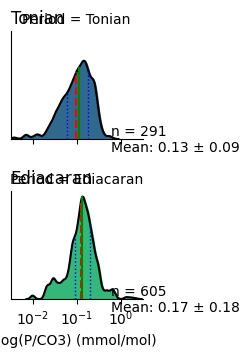

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for log transformation
from scipy import stats # Import for gaussian_kde

# Create a FacetGrid for ridge plot
g = sns.FacetGrid(ridge_plot_neoproterozoic_df, row='Period', hue='Period', aspect=1.25, height=2.0,
                  palette=neoproterozoic_color_map, row_order=plot_order_neoproterozoic)

# Draw the densities
g.map(sns.kdeplot, 'log_total_cap', fill=True, alpha=1, linewidth=1.5, bw_adjust=0.5)
g.map(sns.kdeplot, 'log_total_cap', color='black', bw_adjust=0.5)

# Set the x-axis label
g.set_xlabels('log(P/CO3) (mmol/mol)')

# Remove y-axis labels and ticks for cleaner look
g.set(ylabel="", yticks=[])

# Adjust subplot params for a tight layout
g.fig.subplots_adjust(hspace=-0.7) # Adjusted hspace to accommodate larger plots

# Add titles to each row dynamically and vertical lines for stats
for i, ax in enumerate(g.axes.flat):
    period_name = plot_order_neoproterozoic[i]

    # Get count for the current period from ridge_plot_neoproterozoic_df
    # We need to filter by original period name before log-transforming to get the correct count
    count = ridge_plot_neoproterozoic_df[ridge_plot_neoproterozoic_df['Period'] == period_name]['Total CAP (mmol/mol)'].count()

    # Get stats for annotations (original CAP values)
    stats_row_anno = neoproterozoic_period_stats_for_annotations[neoproterozoic_period_stats_for_annotations['Period'] == period_name].iloc[0]
    mean_cap_anno = stats_row_anno['mean']
    std_cap_anno = stats_row_anno['std']

    # Combine annotations into a single string
    annotation_text = f'n = {count}\nMean: {mean_cap_anno:.2f} \u00B1 {std_cap_anno:.2f}'

    # Place the combined annotation on the right side of the x-axis level
    ax.text(ax.get_xlim()[1] + 0.1, 0, annotation_text, va='center', ha='left', fontsize=10, transform=ax.get_yaxis_transform())

    # Add vertical lines for mean, q25, q75 (from log scale stats)
    stats_row_log = neoproterozoic_period_stats_log[neoproterozoic_period_stats_log['Period'] == period_name].iloc[0]

    # --- Add vertical lines for mean, median, q25, q75 (on log scale) ---
    # Get KDE data from the plotted line for interpolation
    if len(ax.lines) > 0:
        x_kde, y_kde = ax.lines[0].get_data() # Get data from the first KDE line
        if len(x_kde) > 1 and len(y_kde) > 1:
            # Function to get density at a given x-value from KDE data
            def get_density_at_x(x_val, x_kde, y_kde):
                return np.interp(x_val, x_kde, y_kde)

            # Plot lines up to the ridge outline, using stats_row_log (log scale)
            mean_y_density = get_density_at_x(stats_row_log['mean'], x_kde, y_kde)
            median_y_density = get_density_at_x(stats_row_log['median'], x_kde, y_kde)
            q25_y_density = get_density_at_x(stats_row_log['q25'], x_kde, y_kde)
            q75_y_density = get_density_at_x(stats_row_log['q75'], x_kde, y_kde)

            ax.plot([stats_row_log['mean'], stats_row_log['mean']], [0, mean_y_density], color='red', linestyle='--', linewidth=1.5, zorder=3)
            ax.plot([stats_row_log['median'], stats_row_log['median']], [0, median_y_density], color='green', linestyle='-', linewidth=1.5, zorder=3) # Median line
            ax.plot([stats_row_log['q25'], stats_row_log['q25']], [0, q25_y_density], color='blue', linestyle=':', linewidth=1.0, zorder=3)
            ax.plot([stats_row_log['q75'], stats_row_log['q75']], [0, q75_y_density], color='blue', linestyle=':', linewidth=1.0, zorder=3)

    # Set title for each subplot
    ax.set_title(period_name, loc='left', fontsize=12)

# Define custom ticks for log scale
log_ticks = [-2, -1, 0] # Corresponds to 0.01, 0.1, 1.0
log_labels = [f'$10^{{{int(t)}}}$' for t in log_ticks]

# Set a consistent x-axis limit for all plots and custom ticks for log scale
g.set(xlim=(-2.5, 0.5), xticks=log_ticks, xticklabels=log_labels)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle

# Save the figure as a PDF
output_pdf_path_ridge_neoproterozoic = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Neoproterozoic_CAP_Ridge_Plot_LogScale_NoMackenzie.pdf" # Changed filename to reflect exclusion
plt.savefig(output_pdf_path_ridge_neoproterozoic)
print(f"Figure successfully saved to {output_pdf_path_ridge_neoproterozoic}")

plt.show()

In [ ]:
import seaborn as sns

# 1. Create a DataFrame that pairs 'Formation' and 'Location' from df_tonian_plot
#    and drop duplicates to get unique pairs.
formation_location_pairs = df_tonian_plot[['Formation', 'Location']].drop_duplicates().copy()

# 2. Sort this DataFrame first by 'Location' and then by 'Formation'
sorted_formation_location_pairs = formation_location_pairs.sort_values(by=['Location', 'Formation'])

# 3. Extract the ordered list of 'Formation' names
custom_formation_order = sorted_formation_location_pairs['Formation'].tolist()

# 4. Generate a color palette for the formations
# The number of colors should match the number of unique formations
formation_palette_colors = sns.color_palette("viridis", n_colors=len(custom_formation_order))

# 5. Create a dictionary to map formation names to colors for consistent coloring
formation_color_map = {formation: color for formation, color in zip(custom_formation_order, formation_palette_colors)}

print("Custom formation order created successfully:")
print(custom_formation_order)
print("Formation color map created successfully:")
print(formation_color_map)

NameError: name 'df_tonian_plot' is not defined

Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Formations_Boxplot_GroupedByLocation.pdf


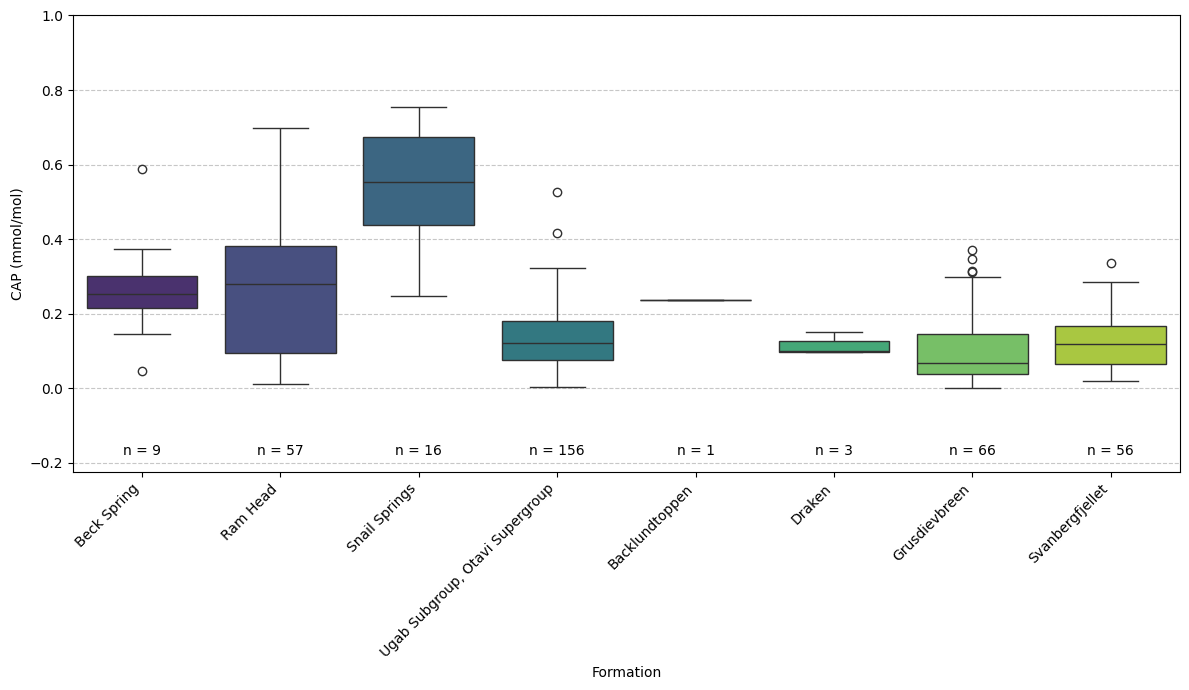

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the box-and-whisker plot
plt.figure(figsize=(12, 7)) # Adjusted figure size for better readability with more formations

ax = sns.boxplot(x='Formation', y='Total CAP (mmol/mol)', data=df_tonian_plot,
                 palette=formation_color_map,
                 order=custom_formation_order,
                 hue='Formation', legend=False) # Use hue for coloring based on formation_color_map

# 2. Add 'n=' annotations for each formation
# Calculate counts for each formation
counts_tonian = df_tonian_plot.groupby('Formation')['Total CAP (mmol/mol)'].count().reset_index(name='Count')

# Define fixed y-position for n= label at the bottom
y_n_label_position_tonian = -0.15 # Adjust as needed to be clearly below the x-axis

for i, formation_name in enumerate(custom_formation_order):
    count = counts_tonian[counts_tonian['Formation'] == formation_name]['Count'].iloc[0] if formation_name in counts_tonian['Formation'].values else 0
    plt.text(i, y_n_label_position_tonian, f'n = {count}', ha='center', va='top', fontsize=10, color='black')

# 3. Set plot title, labels, and grid
#plt.title('Total CAP (mmol/mol) by Tonian Formation (Ordered by Location)')
plt.xlabel('Formation')
plt.ylabel('CAP (mmol/mol)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# 5. Set y-axis limit up to 1.0 and adjust bottom for labels
plt.ylim(top=1.0, bottom=y_n_label_position_tonian * 1.5)

plt.tight_layout()

# 6. Save the figure as a PDF
output_pdf_path_tonian_boxplot = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Formations_Boxplot_GroupedByLocation.pdf"
plt.savefig(output_pdf_path_tonian_boxplot)
print(f"Figure successfully saved to {output_pdf_path_tonian_boxplot}")

plt.show()

# Perform statistical comparisons of the Tonian data with and without the carbon isotope anomaly intervals as well as with and without the units assessed as altered.


In [ ]:
import scipy.stats as stats
import pandas as pd

# Filter the combined dataframe for the Tonian period
tonian_df = filtered_df[filtered_df['Period'] == 'Tonian'].copy()

# Filter for Tonian rows with Anomaly Stage = "BSA"
tonian_bsa_df = tonian_df[tonian_df['Anomaly Stage'] == 'BSA'].copy()

# Filter for Tonian rows *excluding* Anomaly Stage = "BSA"
tonian_non_bsa_df = tonian_df[tonian_df['Anomaly Stage'] != 'BSA'].copy()


# Ensure 'Total CAP (mmol/mol)' is numeric and handle NaNs for both dataframes
tonian_bsa_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_bsa_df['Total CAP (mmol/mol)'], errors='coerce')
tonian_non_bsa_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_non_bsa_df['Total CAP (mmol/mol)'], errors='coerce')

# Extract the 'Total CAP (mmol/mol)' values, dropping NaNs
cap_bsa_tonian = tonian_bsa_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_tonian = tonian_non_bsa_df['Total CAP (mmol/mol)'].dropna()

print(f"Number of Tonian BSA samples: {len(cap_bsa_tonian)}")
print(f"Number of Tonian non-BSA samples: {len(cap_non_bsa_tonian)}")

# Perform Mann-Whitney U test if both groups have sufficient data
if len(cap_bsa_tonian) > 0 and len(cap_non_bsa_tonian) > 0:
    u_statistic_tonian, p_value_tonian = stats.mannwhitneyu(cap_bsa_tonian, cap_non_bsa_tonian, alternative='two-sided')

    print("\n--- Mann-Whitney U Test Results (Tonian BSA vs. Non-BSA) ---")
    print(f"U-statistic: {u_statistic_tonian:.4f}")
    print(f"P-value: {p_value_tonian:.4f}")

    if p_value_tonian < 0.05:
        print("The difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Tonian groups is statistically significant (p < 0.05).")
    else:
        print("There is no statistically significant difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Tonian groups (p >= 0.05).")
else:
    print("Insufficient data in one or both Tonian groups to perform the Mann-Whitney U test.")

Number of Tonian BSA samples: 91
Number of Tonian non-BSA samples: 273

--- Mann-Whitney U Test Results (Tonian BSA vs. Non-BSA) ---
U-statistic: 11311.0000
P-value: 0.2016
There is no statistically significant difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Tonian groups (p >= 0.05).


/tmp/ipykernel_2714/1350020469.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neoproterozoic_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
/tmp/ipykernel_2714/1350020469.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neoproterozoic_non_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA'].copy()
/tmp/ipykernel_2714/1350020469.py:47: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neoproterozoic_bsa_mackenzie_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Mackenzie Mountains, NW Canada'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
/tmp/ipykernel_2714/1350020469.py:48: UserWarning: Boolean Series key will be reindexed to 

Number of BSA samples from Svalbard: 73
Number of non-BSA samples from Svalbard: 53

--- Mann-Whitney U Test Results (Neoproterozoic BSA vs. Non-BSA in Svalbard) ---
U-statistic: 2428.0000
P-value: 0.0148
The difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Neoproterozoic groups in Svalbard is statistically significant (p < 0.05).

Number of BSA samples from Mackenzie Mountains: 18
Number of non-BSA samples from Mackenzie Mountains: 55

--- Mann-Whitney U Test Results (Neoproterozoic BSA vs. Non-BSA in Mackenzie Mountains) ---
U-statistic: 331.0000
P-value: 0.0364
The difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Neoproterozoic groups in Mackenzie Mountains is statistically significant (p < 0.05).
Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/CAP_Location_Anomaly_Comparison_boxplot.pdf


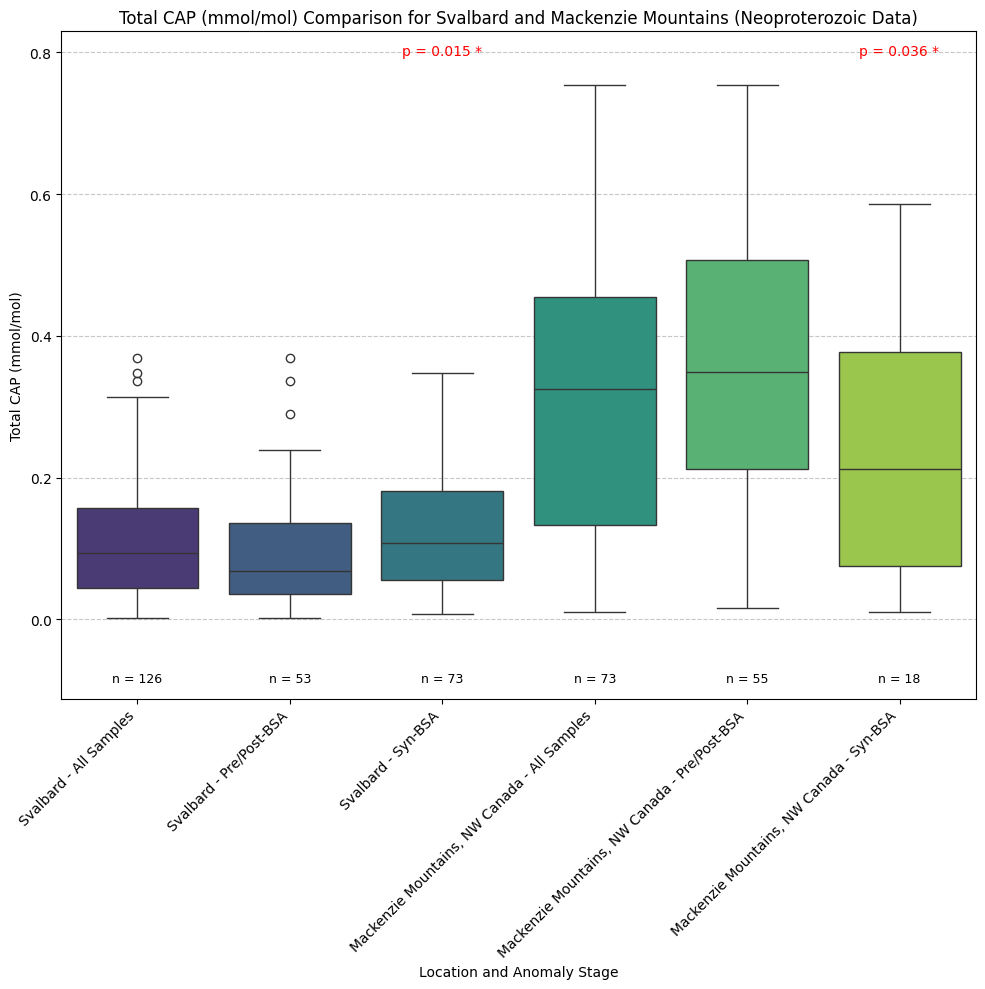

In [ ]:
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure neoprooproterozoic_raw_data is defined for this cell
neoproterozoic_periods = ['Tonian', 'Ediacaran']
neoprooproterozoic_raw_data = filtered_df[filtered_df['Period'].isin(neoproterozoic_periods)].copy()

# --- Mann-Whitney U Test for Svalbard (Existing Code) ---

# Filter neoproterozoic_bsa_df and neoproterozoic_non_bsa_df for 'Svalbard' samples only
neoproterozoic_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
neoproterozoic_non_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA'].copy()

# Ensure 'Total CAP (mmol/mol)' is numeric and handle NaNs for both dataframes
neoproterozoic_bsa_svalbard_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_bsa_svalbard_df['Total CAP (mmol/mol)'], errors='coerce')
neoproterozoic_non_bsa_svalbard_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_non_bsa_svalbard_df['Total CAP (mmol/mol)'], errors='coerce')

# Extract the 'Total CAP (mmol/mol)' values, dropping NaNs
cap_bsa_svalbard = neoproterozoic_bsa_svalbard_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_svalbard = neoproterozoic_non_bsa_svalbard_df['Total CAP (mmol/mol)'].dropna()

print(f"Number of BSA samples from Svalbard: {len(cap_bsa_svalbard)}")
print(f"Number of non-BSA samples from Svalbard: {len(cap_non_bsa_svalbard)}")

# Perform Mann-Whitney U test if both groups have sufficient data
if len(cap_bsa_svalbard) > 0 and len(cap_non_bsa_svalbard) > 0:
    u_statistic_svalbard, p_value_svalbard = stats.mannwhitneyu(cap_bsa_svalbard, cap_non_bsa_svalbard, alternative='two-sided')

    print("\n--- Mann-Whitney U Test Results (Neoproterozoic BSA vs. Non-BSA in Svalbard) ---")
    print(f"U-statistic: {u_statistic_svalbard:.4f}")
    print(f"P-value: {p_value_svalbard:.4f}")

    if p_value_svalbard < 0.05:
        print("The difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Neoproterozoic groups in Svalbard is statistically significant (p < 0.05).")
    else:
        print("There is no statistically significant difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Neoproterozoic groups in Svalbard (p >= 0.05).")
else:
    print("Insufficient data in one or both Svalbard groups to perform the Mann-Whitney U test.")
    p_value_svalbard = 1.0 # Assign a non-significant p-value if test cannot be performed


# --- Mann-Whitney U Test for Mackenzie Mountains (New Code) ---

# Filter neoproterozoic_bsa_df and neoproterozoic_non_bsa_df for 'Mackenzie Mountains, NW Canada' samples only
neoproterozoic_bsa_mackenzie_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Mackenzie Mountains, NW Canada'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
neoproterozoic_non_bsa_mackenzie_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Mackenzie Mountains, NW Canada'][neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA'].copy()


# Ensure 'Total CAP (mmol/mol)' is numeric and handle NaNs for both dataframes
neoproterozoic_bsa_mackenzie_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_bsa_mackenzie_df['Total CAP (mmol/mol)'], errors='coerce')
neoproterozoic_non_bsa_mackenzie_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_non_bsa_mackenzie_df['Total CAP (mmol/mol)'], errors='coerce')

# Extract the 'Total CAP (mmol/mol)' values, dropping NaNs
cap_bsa_mackenzie = neoproterozoic_bsa_mackenzie_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_mackenzie = neoproterozoic_non_bsa_mackenzie_df['Total CAP (mmol/mol)'].dropna()

print(f"\nNumber of BSA samples from Mackenzie Mountains: {len(cap_bsa_mackenzie)}")
print(f"Number of non-BSA samples from Mackenzie Mountains: {len(cap_non_bsa_mackenzie)}")

# Perform Mann-Whitney U test if both groups have sufficient data
if len(cap_bsa_mackenzie) > 0 and len(cap_non_bsa_mackenzie) > 0:
    u_statistic_mackenzie, p_value_mackenzie = stats.mannwhitneyu(cap_bsa_mackenzie, cap_non_bsa_mackenzie, alternative='two-sided')

    print("\n--- Mann-Whitney U Test Results (Neoproterozoic BSA vs. Non-BSA in Mackenzie Mountains) ---")
    print(f"U-statistic: {u_statistic_mackenzie:.4f}")
    print(f"P-value: {p_value_mackenzie:.4f}")

    if p_value_mackenzie < 0.05:
        print("The difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Neoproterozoic groups in Mackenzie Mountains is statistically significant (p < 0.05).")
    else:
        print("There is no statistically significant difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Neoproterozoic groups in Mackenzie Mountains (p >= 0.05).")
else:
    print("Insufficient data in one or both Mackenzie Mountains groups to perform the Mann-Whitney U test.")
    p_value_mackenzie = 1.0 # Assign a non-significant p-value if test cannot be performed


# --- Box Plot for Svalbard and Mackenzie Mountains ---

plot_data = []
locations_to_plot = ['Svalbard', 'Mackenzie Mountains, NW Canada']

# Ensure neoprooproterozoic_raw_data is available and numeric
neoprooproterozoic_raw_data['Total CAP (mmol/mol)'] = pd.to_numeric(neoprooproterozoic_raw_data['Total CAP (mmol/mol)'], errors='coerce')

for location in locations_to_plot:
    # All samples for the location
    df_all = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == location].copy()
    df_all['Group_Type'] = 'All Samples'
    df_all['Location_Group'] = f"{location} - All Samples"
    plot_data.append(df_all[['Total CAP (mmol/mol)', 'Group_Type', 'Location_Group']])

    # Pre/Post-BSA for the location
    df_non_bsa = neoprooproterozoic_raw_data[(neoprooproterozoic_raw_data['Location'] == location) & (neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA')].copy()
    df_non_bsa['Group_Type'] = 'Pre/Post-BSA'
    df_non_bsa['Location_Group'] = f"{location} - Pre/Post-BSA"
    plot_data.append(df_non_bsa[['Total CAP (mmol/mol)', 'Group_Type', 'Location_Group']])

    # Syn-BSA for the location
    df_bsa = neoprooproterozoic_raw_data[(neoprooproterozoic_raw_data['Location'] == location) & (neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA')].copy()
    df_bsa['Group_Type'] = 'Syn-BSA'
    df_bsa['Location_Group'] = f"{location} - Syn-BSA"
    plot_data.append(df_bsa[['Total CAP (mmol/mol)', 'Group_Type', 'Location_Group']])

combined_plot_df = pd.concat(plot_data, ignore_index=True)
combined_plot_df.dropna(subset=['Total CAP (mmol/mol)'], inplace=True)

# Define the order for plotting on the x-axis
plot_order = [
    'Svalbard - All Samples', 'Svalbard - Pre/Post-BSA', 'Svalbard - Syn-BSA',
    'Mackenzie Mountains, NW Canada - All Samples', 'Mackenzie Mountains, NW Canada - Pre/Post-BSA', 'Mackenzie Mountains, NW Canada - Syn-BSA'
]

plt.figure(figsize=(10, 10)) # Make the figure square
ax = sns.boxplot(x='Location_Group', y='Total CAP (mmol/mol)', data=combined_plot_df,
                 order=plot_order, palette='viridis', hue='Location_Group', legend=False)

# Add 'n=' annotations
counts = combined_plot_df.groupby('Location_Group')['Total CAP (mmol/mol)'].count().reset_index(name='Count')

# Dynamically adjust y-position for n= label to be below the lowest data point, with a buffer
min_cap_value = combined_plot_df['Total CAP (mmol/mol)'].min()
max_cap_value = combined_plot_df['Total CAP (mmol/mol)'].max()
y_range = max_cap_value - min_cap_value
y_n_label_position = min_cap_value - y_range * 0.1 # Adjust as needed

for i, group_label in enumerate(plot_order):
    count = counts[counts['Location_Group'] == group_label]['Count'].iloc[0] if group_label in counts['Location_Group'].values else 0
    plt.text(i, y_n_label_position, f'n = {count}', ha='center', va='top', fontsize=9, color='black')

# Add p-values above the relevant violins
# For Svalbard (between Pre/Post-BSA and Syn-BSA)
if 'p_value_svalbard' in locals():
    x_pos_svalbard_bsa_comparison = plot_order.index('Svalbard - Syn-BSA') - 0.5 # Between Pre/Post and Syn
    y_pos_svalbard_bsa_comparison = max_cap_value + y_range * 0.05 # Slightly above max cap
    p_text = f'p = {p_value_svalbard:.3f}' if p_value_svalbard >= 0.001 else 'p < 0.001'
    if p_value_svalbard < 0.05:
        p_text += ' *'
    plt.text(x_pos_svalbard_bsa_comparison + 0.5, y_pos_svalbard_bsa_comparison, p_text, ha='center', va='bottom', fontsize=10, color='red')

# For Mackenzie Mountains (between Pre/Post-BSA and Syn-BSA)
if 'p_value_mackenzie' in locals():
    x_pos_mackenzie_bsa_comparison = plot_order.index('Mackenzie Mountains, NW Canada - Syn-BSA') - 0.5 # Between Pre/Post and Syn
    y_pos_mackenzie_bsa_comparison = max_cap_value + y_range * 0.05 # Slightly above max cap
    p_text = f'p = {p_value_mackenzie:.3f}' if p_value_mackenzie >= 0.001 else 'p < 0.001'
    if p_value_mackenzie < 0.05:
        p_text += ' *'
    plt.text(x_pos_mackenzie_bsa_comparison + 0.5, y_pos_mackenzie_bsa_comparison, p_text, ha='center', va='bottom', fontsize=10, color='red')

plt.title('Total CAP (mmol/mol) Comparison for Svalbard and Mackenzie Mountains (Neoproterozoic Data)')
plt.xlabel('Location and Anomaly Stage')
plt.ylabel('Total CAP (mmol/mol)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis limit to accommodate annotations, ensuring a bit of buffer above max value too
plt.ylim(top=max_cap_value + y_range * 0.1, bottom=y_n_label_position - y_range * 0.05)
plt.tight_layout()

output_pdf_path_location_boxplot = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/CAP_Location_Anomaly_Comparison_boxplot.pdf" # Changed filename
plt.savefig(output_pdf_path_location_boxplot)
print(f"Figure successfully saved to {output_pdf_path_location_boxplot}")
plt.show()

In [ ]:
import scipy.stats as stats

# Perform Mann-Whitney U test between Svalbard and Mackenzie Mountains syn-BSA CAP populations
if len(cap_bsa_svalbard) > 0 and len(cap_bsa_mackenzie) > 0:
    u_statistic_syn_bsa, p_value_syn_bsa = stats.mannwhitneyu(cap_bsa_svalbard, cap_bsa_mackenzie, alternative='two-sided')

    print("\n--- Mann-Whitney U Test Results (Svalbard Syn-BSA vs. Mackenzie Mountains Syn-BSA) ---")
    print(f"U-statistic: {u_statistic_syn_bsa:.4f}")
    print(f"P-value: {p_value_syn_bsa:.4f}")

    if p_value_syn_bsa < 0.05:
        print("The difference in 'Total CAP (mmol/mol)' between Svalbard and Mackenzie Mountains syn-BSA groups is statistically significant (p < 0.05).")
    else:
        print("There is no statistically significant difference in 'Total CAP (mmol/mol)' between Svalbard and Mackenzie Mountains syn-BSA groups (p >= 0.05).")
else:
    print("Insufficient data in one or both syn-BSA groups to perform the Mann-Whitney U test.")


--- Mann-Whitney U Test Results (Svalbard Syn-BSA vs. Mackenzie Mountains Syn-BSA) ---
U-statistic: 451.0000
P-value: 0.0406
The difference in 'Total CAP (mmol/mol)' between Svalbard and Mackenzie Mountains syn-BSA groups is statistically significant (p < 0.05).


In [ ]:
import scipy.stats as stats
import pandas as pd

# Filter for 'Tonian' period within neoproterozoic_bsa_df and neoproterozoic_non_bsa_df
tonian_bsa_df = neoproterozoic_bsa_df[neoproterozoic_bsa_df['Period'] == 'Tonian'].copy()
tonian_non_bsa_df = neoproterozoic_non_bsa_df[neoproterozoic_non_bsa_df['Period'] == 'Tonian'].copy()

# Exclude samples from 'Mackenzie Mountains, NW Canada'
tonian_bsa_filtered_df = tonian_bsa_df[tonian_bsa_df['Location'] != 'Mackenzie Mountains, NW Canada'].copy()
tonian_non_bsa_filtered_df = tonian_non_bsa_df[tonian_non_bsa_df['Location'] != 'Mackenzie Mountains, NW Canada'].copy()

# Ensure 'Total CAP (mmol/mol)' is numeric and handle NaNs for both dataframes
tonian_bsa_filtered_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_bsa_filtered_df['Total CAP (mmol/mol)'], errors='coerce')
tonian_non_bsa_filtered_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_non_bsa_filtered_df['Total CAP (mmol/mol)'], errors='coerce')

# Extract the 'Total CAP (mmol/mol)' values, dropping NaNs
cap_bsa_tonian_filtered = tonian_bsa_filtered_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_tonian_filtered = tonian_non_bsa_filtered_df['Total CAP (mmol/mol)'].dropna()

print(f"Number of BSA samples from Tonian (excluding Mackenzie Mountains): {len(cap_bsa_tonian_filtered)}")
print(f"Number of non-BSA samples from Tonian (excluding Mackenzie Mountains): {len(cap_non_bsa_tonian_filtered)}")

# Perform Mann-Whitney U test if both groups have sufficient data
if len(cap_bsa_tonian_filtered) > 0 and len(cap_non_bsa_tonian_filtered) > 0:
    u_statistic_tonian_filtered, p_value_tonian_filtered = stats.mannwhitneyu(cap_bsa_tonian_filtered, cap_non_bsa_tonian_filtered, alternative='two-sided')

    print("\n--- Mann-Whitney U Test Results (Tonian BSA vs. Non-BSA excluding Mackenzie Mountains) ---")
    print(f"U-statistic: {u_statistic_tonian_filtered:.4f}")
    print(f"P-value: {p_value_tonian_filtered:.4f}")

    if p_value_tonian_filtered < 0.05:
        print("The difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Tonian groups (excluding Mackenzie Mountains) is statistically significant (p < 0.05).")
    else:
        print("There is no statistically significant difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Tonian groups (excluding Mackenzie Mountains) (p >= 0.05).")
else:
    print("Insufficient data in one or both Tonian groups (excluding Mackenzie Mountains) to perform the Mann-Whitney U test.")

Number of BSA samples from Tonian (excluding Mackenzie Mountains): 73
Number of non-BSA samples from Tonian (excluding Mackenzie Mountains): 218

--- Mann-Whitney U Test Results (Tonian BSA vs. Non-BSA excluding Mackenzie Mountains) ---
U-statistic: 7744.0000
P-value: 0.7327
There is no statistically significant difference in 'Total CAP (mmol/mol)' between BSA and non-BSA Tonian groups (excluding Mackenzie Mountains) (p >= 0.05).


### Mean ± Standard Deviation CAP for Tonian Formations

In [ ]:
import pandas as pd

# Combine Tonian BSA and non-BSA dataframes
# These dataframes (tonian_bsa_df, tonian_non_bsa_df) are already filtered for Tonian period
# and contain the 'Anomaly Stage' column.
all_tonian_data_with_anomaly = pd.concat([tonian_bsa_df, tonian_non_bsa_df], ignore_index=True)

# Ensure 'Total CAP (mmol/mol)' is numeric and drop rows with NaN values
all_tonian_data_with_anomaly['Total CAP (mmol/mol)'] = pd.to_numeric(
    all_tonian_data_with_anomaly['Total CAP (mmol/mol)'], errors='coerce'
)
all_tonian_data_with_anomaly.dropna(subset=['Total CAP (mmol/mol)', 'Formation'], inplace=True)

# Calculate mean, std dev, and count for each Formation and Anomaly Stage combination
summary_tonian_anomaly = all_tonian_data_with_anomaly.groupby(['Formation', 'Anomaly Stage'])[
    'Total CAP (mmol/mol)'
].agg(mean='mean', std='std', n='count').reset_index()
summary_tonian_anomaly.columns = [
    'Formation', 'Anomaly Stage', 'Mean CAP (mmol/mol)', 'Std Dev CAP (mmol/mol)', 'n'
]

# Calculate mean, std dev, and count for each Formation overall (ignoring Anomaly Stage)
summary_tonian_overall = all_tonian_data_with_anomaly.groupby('Formation')[
    'Total CAP (mmol/mol)'
].agg(mean='mean', std='std', n='count').reset_index()
summary_tonian_overall.columns = [
    'Formation', 'Mean CAP (mmol/mol)', 'Std Dev CAP (mmol/mol)', 'n'
]
summary_tonian_overall['Anomaly Stage'] = 'Overall'

# Combine overall and anomaly stage summaries and sort for better readability
final_tonian_summary_table = pd.concat([summary_tonian_overall, summary_tonian_anomaly], ignore_index=True)
final_tonian_summary_table.sort_values(by=['Formation', 'Anomaly Stage'], inplace=True)

display(final_tonian_summary_table)

,Formation,Mean CAP (mmol/mol),Std Dev CAP (mmol/mol),n,Anomaly Stage
0,Backlundtoppen,0.235720,NaN,1,Overall
8,Backlundtoppen,0.235720,NaN,1,post-BSA
1,Beck Spring,0.266889,0.151789,9,Overall
2,Draken,0.115848,0.031212,3,Overall
9,Draken,0.115848,0.031212,3,post-BSA
10,Grusdievbreen,0.120601,0.096796,38,BSA
3,Grusdievbreen,0.103725,0.093494,66,Overall
11,Grusdievbreen,0.080823,0.085201,28,pre- BSA
12,Ram Head,0.236116,0.180020,18,BSA
4,Ram Head,0.269979,0.185285,57,Overall


In [ ]:
output_excel_path_tonian_summary_table = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Summary_Table.xlsx"
if 'final_tonian_summary_table' in locals() and not final_tonian_summary_table.empty:
    final_tonian_summary_table.to_excel(output_excel_path_tonian_summary_table, index=False)
    print(f"Summary table successfully saved to {output_excel_path_tonian_summary_table}")
else:
    print("Error: final_tonian_summary_table DataFrame not found or is empty. Please ensure the summary table generation cell has been run.")

Summary table successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Summary_Table.xlsx


In [ ]:
import scipy.stats as stats
import pandas as pd

# Ensure 'tonian_df' is available and 'Total CAP (mmol/mol)' is numeric
tonian_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_df['Total CAP (mmol/mol)'], errors='coerce')

# Group 1: All Tonian data
cap_all_tonian_data = tonian_df['Total CAP (mmol/mol)'].dropna()

# Group 2: Tonian data excluding 'Mackenzie Mountains, NW Canada'
tonian_excluding_mackenzie_df = tonian_df[tonian_df['Location'] != 'Mackenzie Mountains, NW Canada'].copy()
cap_tonian_excluding_mackenzie = tonian_excluding_mackenzie_df['Total CAP (mmol/mol)'].dropna()

print(f"Number of samples in all Tonian data: {len(cap_all_tonian_data)}")
print(f"Number of samples in Tonian data excluding Mackenzie Mountains: {len(cap_tonian_excluding_mackenzie)}")

# Perform Mann-Whitney U test if both groups have sufficient data
if len(cap_all_tonian_data) > 0 and len(cap_tonian_excluding_mackenzie) > 0:
    u_statistic_tonian_all_vs_no_mackenzie, p_value_tonian_all_vs_no_mackenzie = stats.mannwhitneyu(
        cap_all_tonian_data, cap_tonian_excluding_mackenzie, alternative='two-sided'
    )

    print("\n--- Mann-Whitney U Test Results (All Tonian vs. Tonian excluding Mackenzie Mountains) ---")
    print(f"U-statistic: {u_statistic_tonian_all_vs_no_mackenzie:.4f}")
    print(f"P-value: {p_value_tonian_all_vs_no_mackenzie:.4f}")

    if p_value_tonian_all_vs_no_mackenzie < 0.05:
        print("The difference in 'Total CAP (mmol/mol)' between all Tonian data and Tonian data excluding Mackenzie Mountains is statistically significant (p < 0.05).")
    else:
        print("There is no statistically significant difference in 'Total CAP (mmol/mol)' between all Tonian data and Tonian data excluding Mackenzie Mountains (p >= 0.05).")
else:
    print("Insufficient data in one or both groups to perform the Mann-Whitney U test.")

Number of samples in all Tonian data: 364
Number of samples in Tonian data excluding Mackenzie Mountains: 291

--- Mann-Whitney U Test Results (All Tonian vs. Tonian excluding Mackenzie Mountains) ---
U-statistic: 58881.5000
P-value: 0.0139
The difference in 'Total CAP (mmol/mol)' between all Tonian data and Tonian data excluding Mackenzie Mountains is statistically significant (p < 0.05).


<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2714/252129386.py:56: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Comparison of Total CAP (mmol/mol) in Tonian Data with Mean ± 1$\sigma$')
/tmp/ipykernel_2714/252129386.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Group', y='Total CAP (mmol/mol)', data=plot_df, order=plot_order, palette='viridis')


Figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Mackenzie_Comparison_Boxplot.pdf


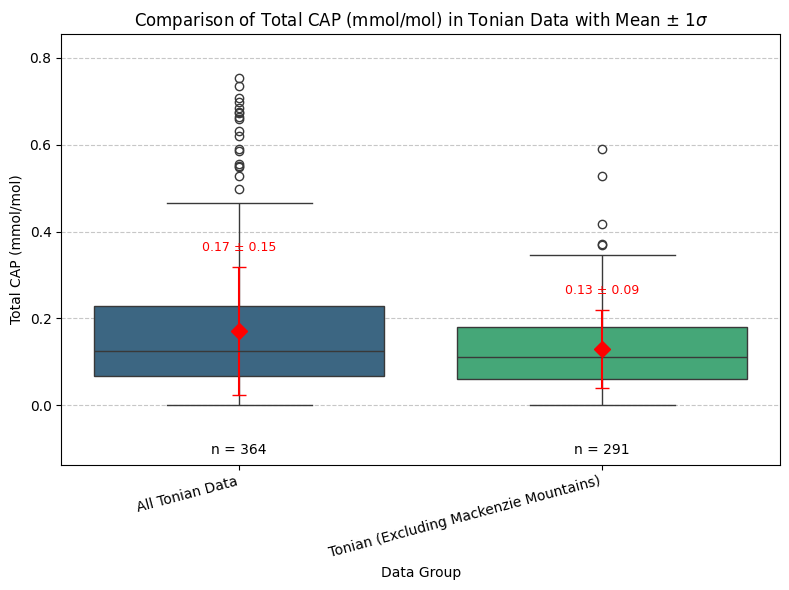

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy for calculations

# Ensure 'tonian_df' is available and 'Total CAP (mmol/mol)' is numeric
tonian_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_df['Total CAP (mmol/mol)'], errors='coerce')

# Prepare data for plotting:
# Group 1: All Tonian data
df_all_tonian = tonian_df.copy()
df_all_tonian['Group'] = 'All Tonian Data'

# Group 2: Tonian data excluding 'Mackenzie Mountains, NW Canada'
df_tonian_no_mackenzie = tonian_df[tonian_df['Location'] != 'Mackenzie Mountains, NW Canada'].copy()
df_tonian_no_mackenzie['Group'] = 'Tonian (Excluding Mackenzie Mountains)'

# Concatenate the two dataframes for plotting
plot_df = pd.concat([df_all_tonian, df_tonian_no_mackenzie], ignore_index=True)

# Drop rows where 'Total CAP (mmol/mol)' is NaN for plotting
plot_df.dropna(subset=['Total CAP (mmol/mol)'], inplace=True)

# Set the order for the groups in the plot
plot_order = ['All Tonian Data', 'Tonian (Excluding Mackenzie Mountains)']

plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='Group', y='Total CAP (mmol/mol)', data=plot_df, order=plot_order, palette='viridis')

# Add 'n=' annotations
counts = plot_df.groupby('Group')['Total CAP (mmol/mol)'].count().reset_index(name='Count')

# Calculate mean and standard deviation for each group
summary_stats = plot_df.groupby('Group')['Total CAP (mmol/mol)'].agg(['mean', 'std']).reset_index()

for i, group_name in enumerate(plot_order):
    count = counts[counts['Group'] == group_name]['Count'].iloc[0] if group_name in counts['Group'].values else 0
    ax.text(i, ax.get_ylim()[0] - 0.05, f'n = {count}', ha='center', va='top', fontsize=10, color='black')

    # Add mean +/- 1 sigma error bars
    mean_val = summary_stats[summary_stats['Group'] == group_name]['mean'].iloc[0]
    std_val = summary_stats[summary_stats['Group'] == group_name]['std'].iloc[0]

    # Plot the mean as a diamond marker
    ax.plot(i, mean_val, marker='D', color='red', markersize=8, zorder=3)

    # Plot the error bars (mean +/- std dev)
    ax.errorbar(i, mean_val, yerr=std_val, color='red', capsize=5, fmt='none', zorder=2)

    # Add text for mean +/- 1 sigma uncertainty above the diamond marker
    text_y_position = mean_val + std_val + 0.03 # Adjust this value to position the text above the error bar
    # Ensure the text is within reasonable y-limits; if it goes too high, adjust position or plot layout.
    ax.text(i, text_y_position, f'{mean_val:.2f} ± {std_val:.2f}', ha='center', va='bottom', fontsize=9, color='red')


plt.title('Comparison of Total CAP (mmol/mol) in Tonian Data with Mean ± 1$\sigma$')
plt.xlabel('Data Group')
plt.ylabel('Total CAP (mmol/mol)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis limit to accommodate the error bars and annotations
# Determine the highest point for the upper y-limit based on mean + std + annotation height
max_upper_val = plot_df['Total CAP (mmol/mol)'].max()
for _, row in summary_stats.iterrows():
    max_upper_val = max(max_upper_val, row['mean'] + row['std'] + 0.05) # 0.05 buffer for text

plt.ylim(top=max_upper_val + 0.1, bottom=ax.get_ylim()[0] - 0.1)
plt.tight_layout()

output_pdf_path = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Mackenzie_Comparison_Boxplot.pdf"
plt.savefig(output_pdf_path)
print(f"Figure successfully saved to {output_pdf_path}")

plt.show()

In [ ]:
import pandas as pd
import scipy.stats as stats

# Ensure filtered_df is defined and 'Total CAP (mmol/mol)' is numeric

# Calculations for 'Tonian BSA vs. Non-BSA (All Locations)'
tonian_df = filtered_df[filtered_df['Period'] == 'Tonian'].copy()
tonian_bsa_df = tonian_df[tonian_df['Anomaly Stage'] == 'BSA'].copy()
tonian_non_bsa_df = tonian_df[tonian_df['Anomaly Stage'] != 'BSA'].copy()

tonian_bsa_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_bsa_df['Total CAP (mmol/mol)'], errors='coerce')
tonian_non_bsa_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_non_bsa_df['Total CAP (mmol/mol)'], errors='coerce')

cap_bsa_tonian = tonian_bsa_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_tonian = tonian_non_bsa_df['Total CAP (mmol/mol)'].dropna()

if len(cap_bsa_tonian) > 0 and len(cap_non_bsa_tonian) > 0:
    u_statistic_tonian, p_value_tonian = stats.mannwhitneyu(cap_bsa_tonian, cap_non_bsa_tonian, alternative='two-sided')
else:
    u_statistic_tonian = float('nan')
    p_value_tonian = float('nan')

# Calculations for 'Svalbard syn-BSA vs. pre/post-BSA' and Mackenzie Mountains
neoproterozoic_periods = ['Tonian', 'Ediacaran']
neoprooproterozoic_raw_data = new_combined_df[new_combined_df['Period'].isin(neoproterozoic_periods)].copy()

neoproterozoic_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
neoproterozoic_non_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA'].copy()

neoproterozoic_bsa_svalbard_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_bsa_svalbard_df['Total CAP (mmol/mol)'], errors='coerce')
neoproterozoic_non_bsa_svalbard_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_non_bsa_svalbard_df['Total CAP (mmol/mol)'], errors='coerce')

cap_bsa_svalbard = neoproterozoic_bsa_svalbard_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_svalbard = neoproterozoic_non_bsa_svalbard_df['Total CAP (mmol/mol)'].dropna()

if len(cap_bsa_svalbard) > 0 and len(cap_non_bsa_svalbard) > 0:
    u_statistic_svalbard, p_value_svalbard = stats.mannwhitneyu(cap_bsa_svalbard, cap_non_bsa_svalbard, alternative='two-sided')
else:
    u_statistic_svalbard = float('nan')
    p_value_svalbard = float('nan')

neoproterozoic_bsa_mackenzie_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Mackenzie Mountains, NW Canada'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
neoproterozoic_non_bsa_mackenzie_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Mackenzie Mountains, NW Canada'][neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA'].copy()

neoproterozoic_bsa_mackenzie_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_bsa_mackenzie_df['Total CAP (mmol/mol)'], errors='coerce')
neoproterozoic_non_bsa_mackenzie_df['Total CAP (mmol/mol)'] = pd.to_numeric(neoproterozoic_non_bsa_mackenzie_df['Total CAP (mmol/mol)'], errors='coerce')

cap_bsa_mackenzie = neoproterozoic_bsa_mackenzie_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_mackenzie = neoproterozoic_non_bsa_mackenzie_df['Total CAP (mmol/mol)'].dropna()

# Calculations for 'Svalbard Syn-BSA vs. Mackenzie Mountains Syn-BSA'
if len(cap_bsa_svalbard) > 0 and len(cap_bsa_mackenzie) > 0:
    u_statistic_syn_bsa, p_value_syn_bsa = stats.mannwhitneyu(cap_bsa_svalbard, cap_bsa_mackenzie, alternative='two-sided')
else:
    u_statistic_syn_bsa = float('nan')
    p_value_syn_bsa = float('nan')

# Calculations for 'Tonian BSA vs. Non-BSA (Excluding Mackenzie Mountains)'
# Re-filter tonian_df for this specific comparison to avoid issues with earlier dataframe definitions
tonian_bsa_df_filtered_for_9c83f82a = tonian_df[tonian_df['Anomaly Stage'] == 'BSA'].copy()
tonian_non_bsa_df_filtered_for_9c83f82a = tonian_df[tonian_df['Anomaly Stage'] != 'BSA'].copy()

tonian_bsa_filtered_df = tonian_bsa_df_filtered_for_9c83f82a[tonian_bsa_df_filtered_for_9c83f82a['Location'] != 'Mackenzie Mountains, NW Canada'].copy()
tonian_non_bsa_filtered_df = tonian_non_bsa_df_filtered_for_9c83f82a[tonian_non_bsa_df_filtered_for_9c83f82a['Location'] != 'Mackenzie Mountains, NW Canada'].copy()

tonian_bsa_filtered_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_bsa_filtered_df['Total CAP (mmol/mol)'], errors='coerce')
tonian_non_bsa_filtered_df['Total CAP (mmol/mol)'] = pd.to_numeric(tonian_non_bsa_filtered_df['Total CAP (mmol/mol)'], errors='coerce')

cap_bsa_tonian_filtered = tonian_bsa_filtered_df['Total CAP (mmol/mol)'].dropna()
cap_non_bsa_tonian_filtered = tonian_non_bsa_filtered_df['Total CAP (mmol/mol)'].dropna()

if len(cap_bsa_tonian_filtered) > 0 and len(cap_non_bsa_tonian_filtered) > 0:
    u_statistic_tonian_filtered, p_value_tonian_filtered = stats.mannwhitneyu(cap_bsa_tonian_filtered, cap_non_bsa_tonian_filtered, alternative='two-sided')
else:
    u_statistic_tonian_filtered = float('nan')
    p_value_tonian_filtered = float('nan')

# Calculations for 'All Tonian vs. Tonian excluding Mackenzie Mountains'
# tonian_df is already defined and numeric from earlier block
cap_all_tonian_data = tonian_df['Total CAP (mmol/mol)'].dropna()
tonian_excluding_mackenzie_df = tonian_df[tonian_df['Location'] != 'Mackenzie Mountains, NW Canada'].copy()
cap_tonian_excluding_mackenzie = tonian_excluding_mackenzie_df['Total CAP (mmol/mol)'].dropna()

if len(cap_all_tonian_data) > 0 and len(cap_tonian_excluding_mackenzie) > 0:
    u_statistic_tonian_all_vs_no_mackenzie, p_value_tonian_all_vs_no_mackenzie = stats.mannwhitneyu(
        cap_all_tonian_data, cap_tonian_excluding_mackenzie, alternative='two-sided'
    )
else:
    u_statistic_tonian_all_vs_no_mackenzie = float('nan')
    p_value_tonian_all_vs_no_mackenzie = float('nan')

# Create a DataFrame to summarize the Mann-Whitney U test results
mann_whitney_results_summary = pd.DataFrame({
    'Test Description': [
        'Tonian BSA vs. Non-BSA (All Locations)',
        'Tonian BSA vs. Non-BSA (Svalbard only)',
        'Tonian BSA vs. Non-BSA (Excluding Mackenzie Mountains)',
        'Svalbard Syn-BSA vs. Mackenzie Mountains Syn-BSA',
        'All Tonian vs. Tonian excluding Mackenzie Mountains'
    ],
    'U-statistic': [
        u_statistic_tonian,
        u_statistic_svalbard,
        u_statistic_tonian_filtered,
        u_statistic_syn_bsa,
        u_statistic_tonian_all_vs_no_mackenzie
    ],
    'P-value': [
        p_value_tonian,
        p_value_svalbard,
        p_value_tonian_filtered,
        p_value_syn_bsa,
        p_value_tonian_all_vs_no_mackenzie
    ],
    'Significance (p < 0.05)': [
        p_value_tonian < 0.05,
        p_value_svalbard < 0.05,
        p_value_tonian_filtered < 0.05,
        p_value_syn_bsa < 0.05,
        p_value_tonian_all_vs_no_mackenzie < 0.05
    ]
})

display(mann_whitney_results_summary)

/tmp/ipykernel_2714/3716342628.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neoproterozoic_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
/tmp/ipykernel_2714/3716342628.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neoproterozoic_non_bsa_svalbard_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Svalbard'][neoprooproterozoic_raw_data['Anomaly Stage'] != 'BSA'].copy()
/tmp/ipykernel_2714/3716342628.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  neoproterozoic_bsa_mackenzie_df = neoprooproterozoic_raw_data[neoprooproterozoic_raw_data['Location'] == 'Mackenzie Mountains, NW Canada'][neoprooproterozoic_raw_data['Anomaly Stage'] == 'BSA'].copy()
/tmp/ipykernel_2714/3716342628.py:43: UserWarning: Boolean Series key will be reindexed to 

,Test Description,U-statistic,P-value,Significance (p < 0.05)
0,Tonian BSA vs. Non-BSA (All Locations),11311.0,0.201629,False
1,Tonian BSA vs. Non-BSA (Svalbard only),2428.0,0.014837,True
2,Tonian BSA vs. Non-BSA (Excluding Mackenzie Mo...,7744.0,0.732740,False
3,Svalbard Syn-BSA vs. Mackenzie Mountains Syn-BSA,451.0,0.040615,True
4,All Tonian vs. Tonian excluding Mackenzie Moun...,58881.5,0.013903,True


In [ ]:
output_excel_path_mann_whitney = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Mann_Whitney_U_Tests_Tonian_Summary.xlsx"
if 'mann_whitney_results_summary' in locals() and not mann_whitney_results_summary.empty:
    mann_whitney_results_summary.to_excel(output_excel_path_mann_whitney, index=False)
    print(f"Summary of Mann-Whitney U tests successfully saved to {output_excel_path_mann_whitney}")
else:
    print("Error: mann_whitney_results_summary DataFrame not found or is empty. Please ensure the summary statistics cell has been run.")

Summary of Mann-Whitney U tests successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Mann_Whitney_U_Tests_Tonian_Summary.xlsx


Read in [P] calculated from pH dependence of CAP and CAP values for aragonite and calcite, only for Namibia and Svalbard localities.

In [ ]:
new_excel_file_path = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/P_Concentrations.xlsx"

# Read the 'Namibia' sheet into a DataFrame
namibia_concP_df = pd.read_excel(new_excel_file_path, sheet_name='Namibia')

# Read the 'Svalbard' sheet into a DataFrame
svalbard_concP_df = pd.read_excel(new_excel_file_path, sheet_name='Svalbard')

print("Namibia DataFrame head:")
display(namibia_concP_df.head())

print("\nSvalbard DataFrame head:")
display(svalbard_concP_df.head())

Namibia DataFrame head:


,Location,Anomaly Stage,Section,Formation,Age (Ma),Sample Number,Composite Height (m),Total CAP (mmol/mol),Total Standard Deviation,DIP_8.5_calcite,DIP_8.7_calcite,DIP_9_calcite,DIP_8.5_arag,DIP_8.7_arag,DIP_9_arag
0,Namibia,Russoya,Rondehoek Farm,"Ugab Subgroup, Otavi Supergroup",735,177.2,141.7,0.003835,0.003645,3.172705,4.612705,6.772705,1.442324,2.349524,3.710324
1,Namibia,Garvellach,Vrede Farm,"Ugab Subgroup, Otavi Supergroup",735,341.0,838.4,0.006970,0.012900,3.235404,4.675404,6.835404,1.481825,2.389025,3.749825
2,Namibia,Russoya,Rondehoek Farm,"Ugab Subgroup, Otavi Supergroup",735,186.9,152.6,0.012596,0.011701,3.347918,4.787918,6.947918,1.552708,2.459908,3.820708
3,Namibia,Garvellach,Vrede Farm,"Ugab Subgroup, Otavi Supergroup",735,365.0,854.5,0.023323,0.002620,3.562458,5.002458,7.162458,1.687869,2.595069,3.955869
4,Namibia,Garvellach,Vrede Farm,"Ugab Subgroup, Otavi Supergroup",735,228.0,762.7,0.030007,0.019427,3.696131,5.136131,7.296131,1.772083,2.679283,4.040083



Svalbard DataFrame head:


,Location,Section,Sample Number,DIP_8.5_calcite,DIP_8.7_calcite,DIP_9_calcite,DIP_8.5_arag,DIP_8.7_arag,DIP_9_arag
0,Svalbard,G205,0.0,10.482473,11.922473,14.082473,6.047478,6.954678,8.315478
1,Svalbard,G312,13.5,3.349922,4.789922,6.949922,1.553971,2.461171,3.821971
2,Svalbard,G312,30.0,5.819782,7.259782,9.419782,3.109982,4.017182,5.377982
3,Svalbard,G312,38.0,3.657811,5.097811,7.257811,1.747941,2.655141,4.015941
4,Svalbard,G205,106.0,4.398979,5.838979,7.998979,2.214877,3.122077,4.482877


In [ ]:
# 1. Filter filtered_df for Svalbard and Tonian period to get 'Composite Height (m)' and 'Section'
svalbard_tonian_height_data = filtered_df[
    (filtered_df['Location'] == 'Svalbard') &
    (filtered_df['Period'] == 'Tonian')
][['Sample Number', 'Section', 'Composite Height (m)']].drop_duplicates(subset=['Sample Number', 'Section'], keep='first').copy()

# 2. Before merging, explicitly remove ALL columns from svalbard_concP_df that might represent 'Composite Height (m)'
# This prevents duplicate columns like '_x', '_y', or multiple plain names from being created.
columns_to_drop = [col for col in svalbard_concP_df.columns if 'Composite Height (m)' in col]
if columns_to_drop:
    svalbard_concP_df = svalbard_concP_df.drop(columns=columns_to_drop)

# 3. Merge svalbard_concP_df with the height data
# Use a left merge to keep all rows from svalbard_concP_df and add matching heights,
# aligning on both 'Sample Number' and 'Section'
svalbard_concP_df = pd.merge(
    svalbard_concP_df,
    svalbard_tonian_height_data,
    on=['Sample Number', 'Section'],
    how='left'
)

print("Updated Svalbard DataFrame head with 'Composite Height (m)':")
display(svalbard_concP_df.head())

Updated Svalbard DataFrame head with 'Composite Height (m)':


,Location,Section,Sample Number,DIP_8.5_calcite,DIP_8.7_calcite,DIP_9_calcite,DIP_8.5_arag,DIP_8.7_arag,DIP_9_arag,Composite Height (m)
0,Svalbard,G205,0.0,10.482473,11.922473,14.082473,6.047478,6.954678,8.315478,-65.0
1,Svalbard,G312,13.5,3.349922,4.789922,6.949922,1.553971,2.461171,3.821971,13.5
2,Svalbard,G312,30.0,5.819782,7.259782,9.419782,3.109982,4.017182,5.377982,30.0
3,Svalbard,G312,38.0,3.657811,5.097811,7.257811,1.747941,2.655141,4.015941,38.0
4,Svalbard,G205,106.0,4.398979,5.838979,7.998979,2.214877,3.122077,4.482877,41.0


Generate a multi-panel figure for the three Tonian-aged localities depicting their CAP, carbonate carbon isotope values, and I/Ca ratios.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec
import pandas as pd # Ensure pandas is imported for reading excel

# Load raw data specifically for Svalbard 87Sr/86Sr to bypass early filters
raw_all_data_sr_df = pd.read_excel(excel_file_path, sheet_name='Tonian')

# Filter for Svalbard and relevant columns
svalbard_87sr_plot_data = raw_all_data_sr_df[
    (raw_all_data_sr_df['Location'] == 'Svalbard')
][['Sample Number', 'Composite Height (m)', '87Sr/86Sr', 'Anomaly Stage']].copy()

# Ensure numeric types and drop NaNs for this specific plot data
svalbard_87sr_plot_data['Composite Height (m)'] = pd.to_numeric(svalbard_87sr_plot_data['Composite Height (m)'], errors='coerce')
svalbard_87sr_plot_data['87Sr/86Sr'] = pd.to_numeric(svalbard_87sr_plot_data['87Sr/86Sr'], errors='coerce')
svalbard_87sr_plot_data.dropna(subset=['Composite Height (m)', '87Sr/86Sr'], inplace=True)

# 1. Data Preparation: Filter filtered_df for 'Tonian' period
tonian_df_raw = filtered_df[filtered_df['Period'] == 'Tonian'].copy()

# Ensure all relevant columns are numeric, coercing errors
numeric_cols = ['Total CAP (mmol/mol)', 'd13Ccarb', 'I/CaMg', 'Composite Height (m)', 'Total Standard Deviation ']
for col in numeric_cols:
    if col in tonian_df_raw.columns:
        tonian_df_raw[col] = pd.to_numeric(tonian_df_raw[col], errors='coerce')


# Further filter for plotting (dropping NaNs in critical columns)
# This dataframe will be the base for all plotting, ensuring 'Composite Height (m)' is always present
tonian_df_base_for_plotting = tonian_df_raw.dropna(subset=['Composite Height (m)']).copy()

print(f"\nShape of tonian_df_base_for_plotting after dropping NaNs in 'Composite Height (m)': {tonian_df_base_for_plotting.shape}")

# Define locations for plotting
locations = ['Svalbard', 'Mackenzie Mountains, NW Canada', 'Namibia']

# Define x-variables and their corresponding pretty labels
x_vars_base = ['Total CAP (mmol/mol)', 'd13Ccarb', 'I/CaMg']
x_labels_base = ['Total CAP (mmol/mol)', 'δ¹³Ccarb (‰ VPDB)', 'I/(Ca+Mg)']

# For Svalbard, we need an additional plot for 87Sr/86Sr
x_vars_svalbard_extended = x_vars_base + ['87Sr/86Sr']
x_labels_svalbard_extended = x_labels_base + ['$^{87}$Sr/$^{86}$Sr']

# Define x-axis limits for each variable
x_axis_limits = {
    'Total CAP (mmol/mol)': (-0.05, 0.85),
    'd13Ccarb': (-5.5, 9.5),
    'I/CaMg': (-0.35, 6.75),
    '87Sr/86Sr': (0.707, 0.709)  # Default limits for 87Sr/86Sr, can be adjusted
}

# Define colormaps for each location's anomaly stages
location_anomaly_palettes = {}
# Generate colors from viridis colormap
viridis_cmap = plt.get_cmap('viridis')
viridis_base_colors = [viridis_cmap(0.1), viridis_cmap(0.5), viridis_cmap(0.9)] # Example base colors

# For each location, generate a set of distinct colors for its unique anomaly stages
color_map_base_viridis_inputs = {
    'Svalbard': viridis_base_colors[0],
    'Mackenzie Mountains, NW Canada': viridis_base_colors[1],
    'Namibia': viridis_base_colors[2]
}

# Define a custom color for 'Russoya' for all locations to override the viridis palette
custom_anomaly_colors = {'Russoya': 'darkolivegreen'}

for loc in locations:
    # Use tonian_df_raw (which includes 'Anomaly Stage' for all data, not just filtered_df)
    unique_anomaly_stages_in_tonian = tonian_df_raw[tonian_df_raw['Location'] == loc]['Anomaly Stage'].dropna().unique()
    num_stages = len(unique_anomaly_stages_in_tonian)
    if num_stages > 0:
        # Generate a palette for the current location using seaborn's light_palette based on a viridis base color
        base_color = color_map_base_viridis_inputs[loc]
        palette = sns.light_palette(base_color, n_colors=num_stages + 2, reverse=True).as_hex()[1:-1] # Get some shades

        # Create the mapping for current location's stages
        current_loc_palette = {stage: palette[i] for i, stage in enumerate(unique_anomaly_stages_in_tonian)}

        # Apply custom overrides if specified
        for stage, color in custom_anomaly_colors.items():
            if stage in current_loc_palette:
                current_loc_palette[stage] = color
        location_anomaly_palettes[loc] = current_loc_palette
    else:
        location_anomaly_palettes[loc] = {} # Empty palette if no stages

# Setup the figure and GridSpec
fig = plt.figure(figsize=(15, 12)) # Adjusted for wider layout with 4 columns
gs = gridspec.GridSpec(3, 4, figure=fig, width_ratios=[1, 1, 1, 1]) # 3 rows, 4 columns, last column for Svalbard only

# Maintain a counter for panel labels (A, B, C...)
panel_label_counter = 0
all_panel_labels = [chr(ord('A') + i) for i in range(10)] # Enough labels for 10 panels

# List to keep track of legend handles and labels per row for combined legends
row_legend_handles = []
row_legend_labels = []
added_moving_avg_to_legend = False # Global flag for moving average legend

# Loop through each location and create subplots
for row_idx, loc in enumerate(locations):
    if loc == 'Svalbard':
        num_cols_in_row = 4
        current_x_vars = x_vars_svalbard_extended
        current_x_labels = x_labels_svalbard_extended
    else:
        num_cols_in_row = 3
        current_x_vars = x_vars_base
        current_x_labels = x_labels_base

    for col_idx, x_var in enumerate(current_x_vars):
        # Only create an axis if it's within the current row's column count
        if col_idx < num_cols_in_row:
            ax = fig.add_subplot(gs[row_idx, col_idx])
            panel_label = all_panel_labels[panel_label_counter]
            ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
            panel_label_counter += 1

            if loc == 'Svalbard' and x_var == '87Sr/86Sr':
                # Use the specifically prepared svalbard_87sr_plot_data
                plot_data_for_panel = svalbard_87sr_plot_data.copy()
            else:
                # Filter data for the current location and drop NaNs for current x_var
                plot_data_for_panel = tonian_df_base_for_plotting[
                    (tonian_df_base_for_plotting['Location'] == loc)
                ].dropna(subset=['Composite Height (m)', x_var]).copy()

            if not plot_data_for_panel.empty:
                # Conditional moving average calculation and plotting
                if not (loc == 'Svalbard' and x_var == '87Sr/86Sr'):
                    # Sort by Composite Height for moving average calculation
                    plot_data_for_panel = plot_data_for_panel.sort_values(by='Composite Height (m)').reset_index(drop=True)

                    # Calculate 5-point moving average
                    window_size = 5
                    min_periods_val = 1
                    plot_data_for_panel['moving_avg'] = plot_data_for_panel[x_var].rolling(
                        window=window_size, center=True, min_periods=min_periods_val
                    ).mean()
                    # Plot 5-point moving average
                    ax.plot(plot_data_for_panel['moving_avg'], plot_data_for_panel['Composite Height (m)'],
                            color='black', linestyle='-', linewidth=2, zorder=3)
                    # Add to legend if not added yet
                    if not added_moving_avg_to_legend:
                        dummy_line, = ax.plot([], [], color='black', linestyle='-', linewidth=2, label='5-point moving average')
                        row_legend_handles.append(dummy_line)
                        row_legend_labels.append('5-point moving average')
                        added_moving_avg_to_legend = True

                # Determine unique anomaly stages for the current plot_data_for_panel
                if 'Anomaly Stage' in plot_data_for_panel.columns and not plot_data_for_panel['Anomaly Stage'].isnull().all():
                    unique_anomaly_stages_in_plot_data = plot_data_for_panel['Anomaly Stage'].dropna().unique()
                    unique_anomaly_stages_in_plot_data.sort() # Ensure consistent order
                else:
                    unique_anomaly_stages_in_plot_data = np.array([])

                # Determine which palette to use for the current plot
                current_plot_palette = location_anomaly_palettes.get(loc, {}) # Default from global
                if loc == 'Svalbard' and x_var == '87Sr/86Sr':
                    # Generate a specific palette for Svalbard 87Sr/86Sr data's anomaly stages
                    sr_anomaly_stages = plot_data_for_panel['Anomaly Stage'].dropna().unique()
                    if len(sr_anomaly_stages) > 0:
                        sr_anomaly_stages.sort()
                        sr_palette_base_color = sns.color_palette("rocket", n_colors=3)[0] # Distinct color for Sr
                        sr_palette_shades = sns.light_palette(sr_palette_base_color, n_colors=len(sr_anomaly_stages) + 2, reverse=True).as_hex()[1:-1]
                        current_plot_palette = {stage: sr_palette_shades[i] for i, stage in enumerate(sr_anomaly_stages)}
                    else:
                        current_plot_palette = {} # No stages in Sr data

                # Collect existing (loc, stage) keys only from the scatter plot entries
                # which are stored as tuples (scatter, loc, stage)
                existing_scatter_legend_keys_for_this_row = set()
                for item in row_legend_handles:
                    if isinstance(item, tuple) and len(item) == 3: # Check if it's a scatter entry
                        _, item_loc, item_stage = item
                        existing_scatter_legend_keys_for_this_row.add((item_loc, item_stage))

                # Plot each anomaly stage separately to get individual legend entries
                for stage in unique_anomaly_stages_in_plot_data:
                    stage_data = plot_data_for_panel[plot_data_for_panel['Anomaly Stage'] == stage]
                    color = current_plot_palette.get(stage, 'gray') # Default to gray if stage not in palette
                    scatter = ax.scatter(stage_data[x_var], stage_data['Composite Height (m)'],
                                         color=color, s=20, label=stage, zorder=2)
                    # Add to legend only if unique (loc, stage) pair for scatter points in this row
                    if (loc, stage) not in existing_scatter_legend_keys_for_this_row:
                        row_legend_handles.append((scatter, loc, stage))
                        row_legend_labels.append(stage)

                # Handle the case where there are no anomaly stages but points exist (e.g., if 'Anomaly Stage' column was dropped or all NaN)
                # This will plot all points in a default color
                if unique_anomaly_stages_in_plot_data.size == 0 and not plot_data_for_panel.empty:
                    scatter = ax.scatter(plot_data_for_panel[x_var], plot_data_for_panel['Composite Height (m)'],
                                         color='gray', s=20, label='Data (no anomaly stage)', zorder=2)
                    if (loc, 'Data (no anomaly stage)') not in existing_scatter_legend_keys_for_this_row:
                        row_legend_handles.append((scatter, loc, 'Data (no anomaly stage)'))
                        row_legend_labels.append('Data (no anomaly stage)')

                # Set x-axis limits
                min_val, max_val = plot_data_for_panel[x_var].min(), plot_data_for_panel[x_var].max()
                buffer = (max_val - min_val) * 0.1 # 10% buffer
                if np.isnan(buffer) or buffer == 0: # Handle case where all values are the same or only one point
                    buffer = 0.05 * abs(min_val) if abs(min_val) > 0 else 0.05 # Small default buffer
                    if buffer == 0: buffer = 0.1 # Ensure a non-zero buffer for single point case

                if x_var in x_axis_limits and x_axis_limits[x_var][0] is not None and x_axis_limits[x_var][1] is not None:
                    ax.set_xlim(x_axis_limits[x_var])
                else:
                    ax.set_xlim(min_val - buffer, max_val + buffer)

                # Dynamically set y-axis limits based on the current location's data to avoid large empty spaces
                min_height, max_height = plot_data_for_panel['Composite Height (m)'].min(), plot_data_for_panel['Composite Height (m)'].max()
                ax.set_ylim(min_height - (max_height - min_height) * 0.1, max_height + (max_height - min_height) * 0.1)

            else:
                ax.text(0.5, 0.5, f"No data for {x_var}", transform=ax.transAxes,
                        ha='center', va='center', fontsize=12, color='gray')
                ax.set_xlim(0, 1) # Set some default limits
                ax.set_ylim(0, 1)

            # Set x-label (only for bottom row or for the last panel of the row if it's the last row)
            if row_idx == len(locations) - 1: # Only for the last row
                ax.set_xlabel(current_x_labels[col_idx])
            else:
                ax.set_xlabel('') # No x-label for middle rows

            # Set y-label (only for the first column)
            if col_idx == 0:
                ax.set_ylabel('Composite Height (m)')
            else:
                ax.set_ylabel('')

            ax.grid(True, linestyle=':', alpha=0.7);
            # Remove tick labels for inner plots to avoid clutter
            if col_idx > 0:
                plt.setp(ax.get_yticklabels(), visible=False)
            if row_idx < len(locations) - 1:
                plt.setp(ax.get_xticklabels(), visible=False)

        # Handle empty panels for non-Svalbard rows (columns 4 onwards)
        else:
            ax = fig.add_subplot(gs[row_idx, col_idx])
            fig.delaxes(ax) # Delete the extra axes if not needed

    # Add combined legend for the current row's anomaly stages and moving average
    # Position the legend outside the plots on the right of the row
    if row_idx == 0: # Only add legend for the first row to avoid duplicates
        unique_legend_elements = {}
        for h_info, label in zip(row_legend_handles, row_legend_labels):
            # Extract actual handle for plotting
            h = h_info[0] if isinstance(h_info, tuple) else h_info
            unique_legend_elements[label] = h

        final_handles = list(unique_legend_elements.values())
        final_labels = list(unique_legend_elements.keys())

        fig.legend(final_handles, final_labels, loc='upper left', bbox_to_anchor=(1.02, 0.95),
                   title='Anomaly Stage', fontsize=8)
    row_legend_handles = [] # Reset for next row
    row_legend_labels = []

    # Add location labels (e.g., 'Svalbard') to the left of each row
    # Corrected y-position for locality labels
    fig.text(0.005, (len(locations) - 1 - row_idx + 0.5) / len(locations), loc, rotation=90, va='center', ha='left',
             fontsize=14, fontweight='bold')

# Set overall title for the figure
fig.suptitle('Geochemical Profiles by Location (Tonian Period)', fontsize=16, y=0.98)

plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95]) # Adjust layout to make space for location labels and suptitle

# Save the figure as a PDF
output_pdf_path_3x3_plot = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Tonian_Composite_Plot_reordered_with_Sr.pdf"
plt.savefig(output_pdf_path_3x3_plot)
print(f"\nFigure successfully saved to {output_pdf_path_3x3_plot}")

plt.show()

NameError: name 'excel_file_path' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter filtered_df for Namibia and Tonian period to get 'Composite Height (m)' and 'Section'
namibia_tonian_height_data = filtered_df[
    (filtered_df['Location'] == 'Namibia') &
    (filtered_df['Period'] == 'Tonian')
][['Sample Number', 'Section', 'Composite Height (m)']].drop_duplicates(subset=['Sample Number', 'Section'], keep='first').copy()

# 2. Before merging, explicitly remove ALL columns from namibia_concP_df that might represent 'Composite Height (m)'
columns_to_drop_namibia = [col for col in namibia_concP_df.columns if 'Composite Height (m)' in col]
if columns_to_drop_namibia:
    namibia_concP_df = namibia_concP_df.drop(columns=columns_to_drop_namibia)

# 3. Merge namibia_concP_df with the height data
# Use a left merge to keep all rows from namibia_concP_df and add matching heights,
# aligning on both 'Sample Number' and 'Section'
namibia_concP_df = pd.merge(
    namibia_concP_df,
    namibia_tonian_height_data,
    on=['Sample Number', 'Section'],
    how='left'
)

# Rename DIP columns to include '_calcite' suffix for consistency with plotting function
# This assumes DIP_8.5, DIP_8.7, DIP_9 in Namibia sheet correspond to the calcite values.
rename_map = {
    'DIP_8.5': 'DIP_8.5_calcite',
    'DIP_8.7': 'DIP_8.7_calcite',
    'DIP_9': 'DIP_9_calcite'
}
namibia_concP_df = namibia_concP_df.rename(columns=rename_map)

print("Updated Namibia DataFrame head with 'Composite Height (m)' and renamed DIP columns:")
display(namibia_concP_df.head())

Updated Namibia DataFrame head with 'Composite Height (m)' and renamed DIP columns:


,Location,Anomaly Stage,Section,Formation,Age (Ma),Sample Number,Total CAP (mmol/mol),Total Standard Deviation,DIP_8.5_calcite,DIP_8.7_calcite,DIP_9_calcite,DIP_8.5_arag,DIP_8.7_arag,DIP_9_arag,Composite Height (m)
0,Namibia,Russoya,Rondehoek Farm,"Ugab Subgroup, Otavi Supergroup",735,177.2,0.003835,0.003645,3.172705,4.612705,6.772705,1.442324,2.349524,3.710324,141.7
1,Namibia,Garvellach,Vrede Farm,"Ugab Subgroup, Otavi Supergroup",735,341.0,0.006970,0.012900,3.235404,4.675404,6.835404,1.481825,2.389025,3.749825,838.4
2,Namibia,Russoya,Rondehoek Farm,"Ugab Subgroup, Otavi Supergroup",735,186.9,0.012596,0.011701,3.347918,4.787918,6.947918,1.552708,2.459908,3.820708,152.6
3,Namibia,Garvellach,Vrede Farm,"Ugab Subgroup, Otavi Supergroup",735,365.0,0.023323,0.002620,3.562458,5.002458,7.162458,1.687869,2.595069,3.955869,854.5
4,Namibia,Garvellach,Vrede Farm,"Ugab Subgroup, Otavi Supergroup",735,228.0,0.030007,0.019427,3.696131,5.136131,7.296131,1.772083,2.679283,4.040083,762.7


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Ensure numpy is imported

def plot_dip_vs_height(df, location_name, output_base_path, ax=None, combined_plot=False, location_base_color=None, custom_colors=None):
    # Ensure relevant columns are numeric
    df['DIP_8.5_calcite'] = pd.to_numeric(df['DIP_8.5_calcite'], errors='coerce')
    df['DIP_8.7_calcite'] = pd.to_numeric(df['DIP_8.7_calcite'], errors='coerce')
    df['Composite Height (m)'] = pd.to_numeric(df['Composite Height (m)'], errors='coerce')

    # Check for DIP_9_calcite and convert if present
    has_dip_9_calcite = 'DIP_9_calcite' in df.columns
    if has_dip_9_calcite:
        df['DIP_9_calcite'] = pd.to_numeric(df['DIP_9_calcite'], errors='coerce')

    # Check for Aragonite DIP columns and convert if present
    has_dip_8_5_arag = 'DIP_8.5_arag' in df.columns
    if has_dip_8_5_arag:
        df['DIP_8.5_arag'] = pd.to_numeric(df['DIP_8.5_arag'], errors='coerce')

    has_dip_8_7_arag = 'DIP_8.7_arag' in df.columns
    if has_dip_8_7_arag:
        df['DIP_8.7_arag'] = pd.to_numeric(df['DIP_8.7_arag'], errors='coerce')

    has_dip_9_arag = 'DIP_9_arag' in df.columns
    if has_dip_9_arag:
        df['DIP_9_arag'] = pd.to_numeric(df['DIP_9_arag'], errors='coerce')

    # Drop rows with NaN in critical plotting columns (calcite values as primary)
    plot_df = df.dropna(subset=['DIP_8.5_calcite', 'DIP_8.7_calcite', 'Composite Height (m)']).copy()
    if has_dip_9_calcite:
        plot_df = plot_df.dropna(subset=['DIP_9_calcite'])

    # Sort by Composite Height (m) for running average calculation
    plot_df = plot_df.sort_values(by='Composite Height (m)').reset_index(drop=True)

    # Calculate weighted running averages (using rolling mean for simplicity)
    window_size = 5 # Example window size, adjust as needed
    min_periods_val = 1 # Allow calculation as long as there is at least one data point in the window

    plot_df['rolling_DIP_8.7'] = plot_df['DIP_8.7_calcite'].rolling(window=window_size, center=True, min_periods=min_periods_val).mean()
    plot_df['rolling_DIP_8.5'] = plot_df['DIP_8.5_calcite'].rolling(window=window_size, center=True, min_periods=min_periods_val).mean()
    if has_dip_9_calcite:
        plot_df['rolling_DIP_9'] = plot_df['DIP_9_calcite'].rolling(window=window_size, center=True, min_periods=min_periods_val).mean()

    if has_dip_8_5_arag:
        plot_df['rolling_DIP_8.5_arag'] = plot_df['DIP_8.5_arag'].rolling(window=window_size, center=True, min_periods=min_periods_val).mean()
    if has_dip_8_7_arag:
        plot_df['rolling_DIP_8.7_arag'] = plot_df['DIP_8.7_arag'].rolling(window=window_size, center=True, min_periods=min_periods_val).mean()
    if has_dip_9_arag:
        plot_df['rolling_DIP_9_arag'] = plot_df['DIP_9_arag'].rolling(window=window_size, center=True, min_periods=min_periods_val).mean()

    # Determine which axes to plot on
    if ax is None:
        fig, current_ax = plt.subplots(figsize=(8, 10))
        individual_plot = True
    else:
        current_ax = ax
        individual_plot = False

    # --- Dynamic color assignment based on location_base_color or custom_colors ---
    if custom_colors is not None:
        # Use custom colors if provided
        actual_arag_scatter_color = custom_colors.get('actual_arag_scatter_color', 'darkred')
        calcite_8_7_color = custom_colors.get('calcite_8_7_color', 'darkblue')
        calcite_8_5_color = custom_colors.get('calcite_8_5_color', 'royalblue')
        calcite_9_color = custom_colors.get('calcite_9_color', 'skyblue')
        aragonite_8_5_color = custom_colors.get('aragonite_8_5_color', 'lightpink')
        aragonite_8_7_color = custom_colors.get('aragonite_8_7_color', 'salmon')
        aragonite_9_color = custom_colors.get('aragonite_9_color', 'red')
    elif location_base_color is not None:
        # Generate shades for Calcite (darker end of the palette)
        calcite_shades = sns.light_palette(location_base_color, n_colors=4, reverse=True).as_hex()
        calcite_8_7_color = calcite_shades[0] # Darkest
        calcite_8_5_color = calcite_shades[1]
        calcite_9_color = calcite_shades[2]

        # Generate shades for Aragonite (lighter end of the palette)
        aragonite_shades = sns.light_palette(location_base_color, n_colors=4).as_hex()
        aragonite_8_5_color = aragonite_shades[0] # Lightest
        aragonite_8_7_color = aragonite_shades[1]
        aragonite_9_color = aragonite_shades[2]

        # Use a slightly more distinct color for the scatter points for visibility
        actual_arag_scatter_color = aragonite_shades[3] # Darker end of aragonite shades
    else:
        # Fallback to default colors if no base_color or custom_colors is provided
        calcite_8_7_color = 'darkblue'
        calcite_8_5_color = 'royalblue'
        calcite_9_color = 'skyblue'
        aragonite_8_5_color = 'lightpink'
        aragonite_8_7_color = 'salmon'
        aragonite_9_color = 'red'
        actual_arag_scatter_color = 'darkred'


    # Plot actual DIP_8.7_arag values as circles
    if has_dip_8_7_arag:
        current_ax.scatter(plot_df['DIP_8.7_arag'], plot_df['Composite Height (m)'],
                        color=actual_arag_scatter_color, s=30, alpha=0.7, label='Actual DIP_8.7_arag (Aragonite)')

    # Plot thick line for weighted running average of DIP_8.7_calcite
    current_ax.plot(plot_df['rolling_DIP_8.7'], plot_df['Composite Height (m)'],
                    color=calcite_8_7_color, linewidth=3, alpha = 0.5, label='Rolling Avg. DIP_8.7_calcite')

    # Plot lines for weighted running averages of DIP_8.5_calcite
    current_ax.plot(plot_df['rolling_DIP_8.5'], plot_df['Composite Height (m)'],
                    color=calcite_8_5_color, linewidth=1.5, alpha = 0.5, linestyle='--', label='Rolling Avg. DIP_8.5_calcite')

    # Plot line for weighted running average of DIP_9_calcite (if available)
    if has_dip_9_calcite:
        current_ax.plot(plot_df['rolling_DIP_9'], plot_df['Composite Height (m)'],
                        color=calcite_9_color, linewidth=1.5, alpha = 0.5, linestyle='--', label='Rolling Avg. DIP_9_calcite')

    # Plot lines for weighted running averages of Aragonite DIP values (if available)
    if has_dip_8_5_arag:
        current_ax.plot(plot_df['rolling_DIP_8.5_arag'], plot_df['Composite Height (m)'],
                        color=aragonite_8_5_color, linewidth=1.5, linestyle='--', label='Rolling Avg. DIP_8.5_arag')
    if has_dip_8_7_arag:
        current_ax.plot(plot_df['rolling_DIP_8.7_arag'], plot_df['Composite Height (m)'],
                        color=aragonite_8_7_color, linewidth=1.5, linestyle='-', label='Rolling Avg. DIP_8.7_arag')
    if has_dip_9_arag:
        current_ax.plot(plot_df['rolling_DIP_9_arag'], plot_df['Composite Height (m)'],
                        color=aragonite_9_color, linewidth=1.5, linestyle='--', label='Rolling Avg. DIP_9_arag')

    current_ax.set_xlabel('Dissolved Inorganic Phosphate (µM)')
    current_ax.set_ylabel('Composite Height (m)')
    if not combined_plot: # Only set title if it's an individual plot or not explicitly for a combined one
        current_ax.set_title(f'DIP vs. Composite Height in {location_name}')
    current_ax.grid(True, linestyle='--', alpha=0.6)
    current_ax.legend(loc='best', fontsize=8)

    # Set x-axis limits from 0 to 20 micromolar DIP
    current_ax.set_xlim(0, 20)

    # Add a vertical gray line at DIP = 2 micromolar
    current_ax.axvline(x=2, color='gray', linestyle='-', linewidth=1.5, alpha=0.7)

    # Add horizontal black bars
    # Get the maximum y-value (top of the plot) for placing the bars
    max_y = plot_df['Composite Height (m)'].max()
    # Adjust position for the bars above the rolling average lines
    if np.isfinite(max_y):
        bar_offset_1 = max_y * 0.05 # first bar 5% above max_y
        bar_offset_2 = max_y * 0.10 # second bar 10% above max_y
    else: # Fallback for empty df or all NaN heights
        bar_offset_1 = 10 # arbitrary small offset
        bar_offset_2 = 20 # arbitrary small offset
        max_y = current_ax.get_ylim()[1] # Use current y-limit top if no data

    current_ax.hlines(y=max_y + bar_offset_1, xmin=3.8, xmax=7.8, color='black', linewidth=4)
    current_ax.hlines(y=max_y + bar_offset_2, xmin=3, xmax=20, color='black', linewidth=4)

    if individual_plot:
        plt.tight_layout()
        output_pdf_path = f"{output_base_path}/{location_name}_DIP_vs_Height_Plot.pdf"
        plt.savefig(output_pdf_path)
        print(f"Figure successfully saved to {output_pdf_path}")
        plt.show()
    return current_ax # Return the axes object for further manipulation in combined plot

# Define the base path for saving figures
figures_output_path = "/content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures"

Combined figure successfully saved to /content/drive/MyDrive/Proposals_and_Grants/CAREER/Proterozoic_CAP/Figures/Combined_Svalbard_Namibia_DIP_vs_Height_Plot_Colored.pdf


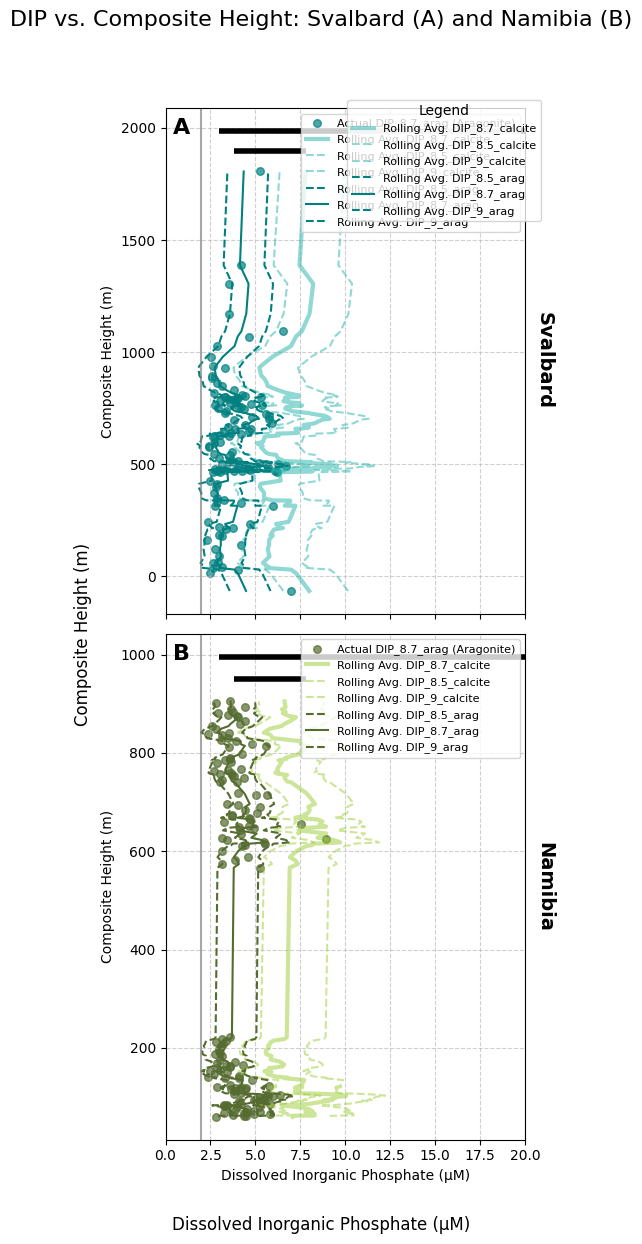

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-define viridis_cmap and viridis_base_colors for access within this cell
viridis_cmap = plt.get_cmap('viridis')
viridis_base_colors = [viridis_cmap(0.1), viridis_cmap(0.5), viridis_cmap(0.9)] # Pick 3 distinct colors from viridis

# Define custom color configurations
svalbard_colors = {
    'actual_arag_scatter_color': '#008080', # Darker teal
    'aragonite_8_5_color': '#008080',
    'aragonite_8_7_color': '#008080',
    'aragonite_9_color': '#008080',
    'calcite_8_7_color': '#20B2AA', # Very light teal
    'calcite_8_5_color': '#20B2AA',
    'calcite_9_color': '#20B2AA',
}

namibia_colors = {
    'actual_arag_scatter_color': '#556B2F', # darkolivegreen
    'aragonite_8_5_color': '#556B2F',
    'aragonite_8_7_color': '#556B2F',
    'aragonite_9_color': '#556B2F',
    'calcite_8_7_color': '#9ACD32', # YellowGreen
    'calcite_8_5_color': '#9ACD32',
    'calcite_9_color': '#9ACD32',
    # For other Namibia colors, use the default palette generation based on location_base_color
    # The plot_dip_vs_height function will apply these overrides first, then fall back to location_base_color for others
}

# Create a figure with two subplots arranged vertically
fig, axes = plt.subplots(2, 1, figsize=(5, 12), sharex=True) # sharex ensures x-axes are aligned

# Plot Svalbard on the top subplot (axes[0])
# Use combined_plot=True to prevent individual saving/showing and title generation
plot_dip_vs_height(svalbard_concP_df.copy(), 'Svalbard', figures_output_path, ax=axes[0],
                   combined_plot=True, location_base_color=viridis_base_colors[1], custom_colors=svalbard_colors)
axes[0].set_title('') # Clear the individual title that might be set by the function
axes[0].set_xlabel('') # Clear x-label for top plot for cleaner combined view

# Add 'A' label to the upper left corner of the Svalbard plot
axes[0].text(0.02, 0.98, 'A', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
# Add rotated locality label for Svalbard
axes[0].text(1.08, 0.5, 'Svalbard', rotation=270, va='center', ha='right',
             transform=axes[0].transAxes, fontsize=14, fontweight='bold')


# Plot Namibia on the bottom subplot (axes[1])
plot_dip_vs_height(namibia_concP_df.copy(), 'Namibia', figures_output_path, ax=axes[1],
                   combined_plot=True, location_base_color=viridis_base_colors[2], custom_colors=namibia_colors)
axes[1].set_title('') # Clear the individual title that might be set by the function

# Add 'B' label to the upper left corner of the Namibia plot
axes[1].text(0.02, 0.98, 'B', transform=axes[1].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
# Add rotated locality label for Namibia
axes[1].text(1.08, 0.5, 'Namibia', rotation=270, va='center', ha='right',
             transform=axes[1].transAxes, fontsize=14, fontweight='bold')

# Add a common y-label on the left side of the entire figure
fig.text(0.005, 0.5, 'Composite Height (m)', va='center', ha='left', rotation='vertical', fontsize=12)

# Add a common x-label at the bottom of the entire figure
fig.text(0.5, 0.00, 'Dissolved Inorganic Phosphate (µM)', va='bottom', ha='center', fontsize=12)

# Add a title to the entire figure
fig.suptitle('DIP vs. Composite Height: Svalbard (A) and Namibia (B)', fontsize=16, y=1.02)

# --- Consolidated Legend ---
# Get handles and labels from both subplots for a single combined legend
handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()

# Combine unique handles and labels.
unique_labels_dict = {}
for h, l in zip(handles0, labels0):
    if l not in unique_labels_dict:
        unique_labels_dict[l] = h
for h, l in zip(handles1, labels1):
    if l not in unique_labels_dict:
        unique_labels_dict[l] = h

# Define the desired order for legend labels
ordered_labels = [
    'Calculated CAP at pH 8.7, aragonite',
    'Rolling Avg. DIP_8.7_calcite',
    'Rolling Avg. DIP_8.5_calcite',
    'Rolling Avg. DIP_9_calcite',
    'Rolling Avg. DIP_8.5_arag',
    'Rolling Avg. DIP_8.7_arag',
    'Rolling Avg. DIP_9_arag'
]

# Filter for existing labels and reorder
final_handles = [unique_labels_dict[l] for l in ordered_labels if l in unique_labels_dict]
final_labels = [l for l in ordered_labels if l in unique_labels_dict]

# Place a single legend for the entire figure
fig.legend(final_handles, final_labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), title='Legend', fontsize=8)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle and common labels

# Save the combined figure
combined_output_pdf_path = f"{figures_output_path}/Combined_Svalbard_Namibia_DIP_vs_Height_Plot_Colored.pdf" # New filename
plt.savefig(combined_output_pdf_path)
print(f"Combined figure successfully saved to {combined_output_pdf_path}")

plt.show()